
# AWS SAAS SALES ANALYSIS - SETUP

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Libraries imported successfully!")
print("📊 Ready to analyze AWS SaaS Sales data")

✅ Libraries imported successfully!
📊 Ready to analyze AWS SaaS Sales data


In [2]:
# ============================================
# LOAD DATA
# ============================================

# Load the dataset (Kaggle auto-mounts it here)
df = pd.read_csv('/kaggle/input/datasets/nnthanh101/aws-saas-sales/SaaS-Sales.csv')

print("="*60)
print("DATASET LOADED SUCCESSFULLY")
print("="*60)
print(f"\n📦 Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n📋 Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i}. {col}")

print("\n" + "="*60)
print("FIRST 5 ROWS")
print("="*60)
display(df.head())

print("\n" + "="*60)
print("LAST 5 ROWS")
print("="*60)
display(df.tail())

print("\n" + "="*60)
print("DATA TYPES")
print("="*60)
print(df.dtypes)

print("\n" + "="*60)
print("BASIC STATISTICS")
print("="*60)
display(df.describe())

DATASET LOADED SUCCESSFULLY

📦 Dataset Shape: 9,994 rows × 19 columns

📋 Column Names:
   1. Row ID
   2. Order ID
   3. Order Date
   4. Date Key
   5. Contact Name
   6. Country
   7. City
   8. Region
   9. Subregion
   10. Customer
   11. Customer ID
   12. Industry
   13. Segment
   14. Product
   15. License
   16. Sales
   17. Quantity
   18. Discount
   19. Profit

FIRST 5 ROWS


,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
0,1,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,Marketing Suite,16GRM07R1K,261.96,2,0.00,41.91
1,2,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,FinanceHub,QLIW57KZUV,731.94,3,0.00,219.58
2,3,AMER-2022-138688,6/13/2022,20220613,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,1056,Energy,Strategic,FinanceHub,JI6BVL70HQ,14.62,2,0.00,6.87
3,4,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,ContactMatcher,DE9GJKGD44,957.58,5,0.45,-383.03
4,5,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,Marketing Suite - Gold,OIF7NY23WD,22.37,2,0.20,2.52



LAST 5 ROWS


,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
9989,9990,EMEA-2020-110422,1/22/2020,20200122,Dan Allan,Germany,Hamburg,EMEA,EU-WEST,Johnson & Johnson,1055,Healthcare,SMB,SaaS Connector Pack,ETHXMB5TMD,25.25,3,0.20,4.10
9990,9991,AMER-2023-121258,2/27/2023,20230227,Anthony Sanderson,United States,Milwaukee,AMER,NAMER,American Express,1005,Finance,SMB,SaaS Connector Pack,LYHOKTRY7L,91.96,2,0.00,15.63
9991,9992,AMER-2023-121258,2/27/2023,20230227,Anthony Sanderson,United States,Milwaukee,AMER,NAMER,American Express,1005,Finance,SMB,Site Analytics,I5SVMI6M88,258.58,2,0.20,19.39
9992,9993,AMER-2023-121258,2/27/2023,20230227,Anthony Sanderson,United States,Milwaukee,AMER,NAMER,American Express,1005,Finance,SMB,Support,JHLW4P6LQ2,29.60,4,0.00,13.32
9993,9994,AMER-2023-119914,5/5/2023,20230505,Jasmine Springer,United States,Dallas,AMER,NAMER,Comcast,1022,Communications,SMB,OneView,3NTBV9B3PS,243.16,2,0.00,72.95



DATA TYPES
Row ID            int64
Order ID         object
Order Date       object
Date Key          int64
Contact Name     object
Country          object
City             object
Region           object
Subregion        object
Customer         object
Customer ID       int64
Industry         object
Segment          object
Product          object
License          object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

BASIC STATISTICS


,Row ID,Date Key,Customer ID,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00
mean,4997.50,20218026.47,1049.77,229.86,3.79,0.16,28.66
std,2885.16,11238.98,29.72,623.25,2.23,0.21,234.26
min,1.00,20200104.00,1001.00,0.44,1.00,0.00,-6599.98
25%,2499.25,20210523.00,1024.00,17.28,2.00,0.00,1.73
50%,4997.50,20220627.00,1049.00,54.49,3.00,0.20,8.67
75%,7495.75,20230515.00,1076.00,209.94,5.00,0.20,29.36
max,9994.00,20231231.00,1101.00,22638.48,14.00,0.80,8399.98


In [3]:
# ============================================
# DATA QUALITY CHECK
# ============================================

print("="*60)
print("DATA QUALITY ASSESSMENT")
print("="*60)

# Dataset info
print("\n📊 Dataset Information:")
df.info()

# Missing values
print("\n" + "="*60)
print("MISSING VALUES ANALYSIS")
print("="*60)

missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df) > 0:
    display(missing_df)
    print(f"\n⚠️ Total missing values: {df.isnull().sum().sum():,}")
else:
    print("✅ No missing values found!")

# Duplicates
print("\n" + "="*60)
print("DUPLICATE ROWS CHECK")
print("="*60)
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates:,} ({duplicates/len(df)*100:.2f}%)")

# Unique values per column
print("\n" + "="*60)
print("UNIQUE VALUES PER COLUMN")
print("="*60)

unique_df = pd.DataFrame({
    'Column': df.columns,
    'Unique_Values': [df[col].nunique() for col in df.columns],
    'Sample_Values': [df[col].unique()[:3].tolist() for col in df.columns]
})
display(unique_df)

DATA QUALITY ASSESSMENT

📊 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Row ID        9994 non-null   int64  
 1   Order ID      9994 non-null   object 
 2   Order Date    9994 non-null   object 
 3   Date Key      9994 non-null   int64  
 4   Contact Name  9994 non-null   object 
 5   Country       9994 non-null   object 
 6   City          9994 non-null   object 
 7   Region        9994 non-null   object 
 8   Subregion     9994 non-null   object 
 9   Customer      9994 non-null   object 
 10  Customer ID   9994 non-null   int64  
 11  Industry      9994 non-null   object 
 12  Segment       9994 non-null   object 
 13  Product       9994 non-null   object 
 14  License       9994 non-null   object 
 15  Sales         9994 non-null   float64
 16  Quantity      9994 non-null   int64  
 17  Discount      9994 non-

,Column,Unique_Values,Sample_Values
0,Row ID,9994,"[1, 2, 3]"
1,Order ID,5009,"[EMEA-2022-152156, AMER-2022-138688, EMEA-2021..."
2,Order Date,1237,"[11/9/2022, 6/13/2022, 10/11/2021]"
3,Date Key,1237,"[20221109, 20220613, 20211011]"
4,Contact Name,793,"[Nathan Bell, Deirdre Bailey, Zoe Hodges]"
5,Country,48,"[Ireland, United States, Germany]"
6,City,262,"[Dublin, New York City, Stuttgart]"
7,Region,3,"[EMEA, AMER, APJ]"
8,Subregion,12,"[UKIR, NAMER, EU-WEST]"
9,Customer,99,"[Chevron, Phillips 66, Royal Dutch Shell]"


In [4]:
# ============================================
# DATA CLEANING
# ============================================

print("="*60)
print("STARTING DATA CLEANING")
print("="*60)

# Create a copy
df_clean = df.copy()
initial_rows = len(df_clean)

# 1. Remove duplicates
print("\n1️⃣ Removing duplicates...")
df_clean = df_clean.drop_duplicates()
removed_duplicates = initial_rows - len(df_clean)
print(f"    Removed {removed_duplicates:,} duplicate rows")

# 2. Handle missing values
print("\n2️⃣ Handling missing values...")
if df_clean.isnull().sum().sum() > 0:
    # Drop columns with >50% missing
    missing_pct = (df_clean.isnull().sum() / len(df_clean) * 100)
    high_missing_cols = missing_pct[missing_pct > 50].index.tolist()
    
    if high_missing_cols:
        print(f"   Dropping columns with >50% missing: {high_missing_cols}")
        df_clean = df_clean.drop(columns=high_missing_cols)
    
    # Fill numerical columns with median
    numerical_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
    for col in numerical_cols:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
            print(f"   Filled {col} with median")
    
    # Fill categorical columns with mode
    categorical_cols = df_clean.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        if df_clean[col].isnull().sum() > 0:
            mode_val = df_clean[col].mode()[0] if not df_clean[col].mode().empty else 'Unknown'
            df_clean[col].fillna(mode_val, inplace=True)
            print(f"   Filled {col} with mode/Unknown")
    
    print(f"    Missing values handled: {df_clean.isnull().sum().sum()} remaining")
else:
    print("    No missing values to handle!")

# 3. Convert data types
print("\n3️⃣ Converting data types...")

# Identify categorical columns (adjust based on YOUR actual columns)
categorical_columns = ['Country', 'City', 'Region', 'Subregion', 
                       'Customer', 'Customer ID', 'Industry', 
                       'Segment', 'Product', 'License']

# Only convert columns that exist
categorical_columns = [col for col in categorical_columns if col in df_clean.columns]

for col in categorical_columns:
    if df_clean[col].nunique() < len(df_clean) * 0.5:  # If less than 50% unique values
        df_clean[col] = df_clean[col].astype('category')

print(f"    Converted {len(categorical_columns)} columns to category type")

print("\n" + "="*60)
print("CLEANING SUMMARY")
print("="*60)
print(f"Original rows: {initial_rows:,}")
print(f"Cleaned rows: {len(df_clean):,}")
print(f"Rows removed: {initial_rows - len(df_clean):,}")
print(f"Final shape: {df_clean.shape}")

STARTING DATA CLEANING

1️⃣ Removing duplicates...
    Removed 0 duplicate rows

2️⃣ Handling missing values...
    No missing values to handle!

3️⃣ Converting data types...
    Converted 10 columns to category type

CLEANING SUMMARY
Original rows: 9,994
Cleaned rows: 9,994
Rows removed: 0
Final shape: (9994, 19)


In [5]:
# ============================================
# OUTLIER DETECTION
# ============================================

print("="*60)
print("OUTLIER DETECTION (IQR Method)")
print("="*60)

numerical_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()

outlier_summary = []

for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
    
    outlier_summary.append({
        'Column': col,
        'Outliers': len(outliers),
        'Percentage': f"{len(outliers)/len(df_clean)*100:.2f}%",
        'Min': df_clean[col].min(),
        'Q1': Q1,
        'Median': df_clean[col].median(),
        'Q3': Q3,
        'Max': df_clean[col].max()
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)

# Create outlier flag
df_clean['has_outlier'] = False
for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_clean.loc[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound), 'has_outlier'] = True

print(f"\nRows with outliers: {df_clean['has_outlier'].sum():,} ({df_clean['has_outlier'].sum()/len(df_clean)*100:.2f}%)")
print("Note: Outliers are flagged but kept for analysis")

OUTLIER DETECTION (IQR Method)


,Column,Outliers,Percentage,Min,Q1,Median,Q3,Max
0,Row ID,0,0.00%,1.00,2499.25,4997.50,7495.75,9994.00
1,Date Key,0,0.00%,20200104.00,20210523.00,20220627.00,20230515.00,20231231.00
2,Sales,1167,11.68%,0.44,17.28,54.49,209.94,22638.48
3,Quantity,170,1.70%,1.00,2.00,3.00,5.00,14.00
4,Discount,856,8.57%,0.00,0.00,0.20,0.20,0.80
5,Profit,1881,18.82%,-6599.98,1.73,8.67,29.36,8399.98



Rows with outliers: 2,851 (28.53%)
Note: Outliers are flagged but kept for analysis


In [6]:
# ============================================
# FEATURE ENGINEERING
# ============================================

print("="*60)
print("FEATURE ENGINEERING")
print("="*60)

initial_features = df_clean.shape[1]

# 1. Profit Margin
df_clean['profit_margin'] = (df_clean['Profit'] / df_clean['Sales']) * 100
print(" Created: profit_margin (Profit/Sales * 100)")

# 2. Average Price Per Unit
df_clean['avg_price_per_unit'] = df_clean['Sales'] / df_clean['Quantity']
print(" Created: avg_price_per_unit (Sales/Quantity)")

# 3. Discount Category
df_clean['discount_category'] = pd.cut(df_clean['Discount'], 
                                         bins=[-0.01, 0, 0.1, 0.2, 1.0],
                                         labels=['No Discount', 'Low (0-10%)', 
                                                'Medium (10-20%)', 'High (>20%)'])
print(" Created: discount_category (Binned discount levels)")

# 4. Deal Size Category
df_clean['deal_size'] = pd.cut(df_clean['Sales'],
                                 bins=[0, 100, 500, 1000, float('inf')],
                                 labels=['Small', 'Medium', 'Large', 'Enterprise'])
print(" Created: deal_size (Deal size categorization)")

# 5. Profitability Flag
df_clean['is_profitable'] = df_clean['Profit'] > 0
print(" Created: is_profitable (Binary profitable flag)")

# 6. High Value Deal (Top 25%)
threshold_75 = df_clean['Sales'].quantile(0.75)
df_clean['high_value_deal'] = df_clean['Sales'] >= threshold_75
print(f" Created: high_value_deal (Sales >= ${threshold_75:.2f})")

# 7. Customer Lifetime Value
customer_clv = df_clean.groupby('Customer')['Sales'].sum().reset_index()
customer_clv.columns = ['Customer', 'customer_lifetime_value']
df_clean = df_clean.merge(customer_clv, on='Customer', how='left')
print(" Created: customer_lifetime_value (Total sales per customer)")

# 8. Customer Purchase Frequency
customer_freq = df_clean.groupby('Customer').size().reset_index()
customer_freq.columns = ['Customer', 'purchase_frequency']
df_clean = df_clean.merge(customer_freq, on='Customer', how='left')
print(" Created: purchase_frequency (Number of purchases per customer)")

# 9. Product Average Profit
product_avg = df_clean.groupby('Product')['Profit'].mean().reset_index()
product_avg.columns = ['Product', 'product_avg_profit']
df_clean = df_clean.merge(product_avg, on='Product', how='left')
print(" Created: product_avg_profit (Avg profit per product)")

# 10. Region Average Sales
region_avg = df_clean.groupby('Region')['Sales'].mean().reset_index()
region_avg.columns = ['Region', 'region_avg_sales']
df_clean = df_clean.merge(region_avg, on='Region', how='left')
print(" Created: region_avg_sales (Avg sales per region)")

# 11. Industry Average Margin
industry_avg = df_clean.groupby('Industry')['profit_margin'].mean().reset_index()
industry_avg.columns = ['Industry', 'industry_avg_margin']
df_clean = df_clean.merge(industry_avg, on='Industry', how='left')
print(" Created: industry_avg_margin (Avg margin per industry)")

# 12. Segment Size
segment_count = df_clean.groupby('Segment').size().reset_index()
segment_count.columns = ['Segment', 'segment_size']
df_clean = df_clean.merge(segment_count, on='Segment', how='left')
print(" Created: segment_size (Number of customers in segment)")

final_features = df_clean.shape[1]
new_features = final_features - initial_features

print("\n" + "="*60)
print(f" Feature Engineering Complete!")
print(f"   Original features: {initial_features}")
print(f"   New features added: {new_features}")
print(f"   Total features: {final_features}")
print("="*60)

FEATURE ENGINEERING
 Created: profit_margin (Profit/Sales * 100)
 Created: avg_price_per_unit (Sales/Quantity)
 Created: discount_category (Binned discount levels)
 Created: deal_size (Deal size categorization)
 Created: is_profitable (Binary profitable flag)
 Created: high_value_deal (Sales >= $209.94)
 Created: customer_lifetime_value (Total sales per customer)
 Created: purchase_frequency (Number of purchases per customer)
 Created: product_avg_profit (Avg profit per product)
 Created: region_avg_sales (Avg sales per region)
 Created: industry_avg_margin (Avg margin per industry)
 Created: segment_size (Number of customers in segment)

 Feature Engineering Complete!
   Original features: 20
   New features added: 12
   Total features: 32


In [7]:
# ============================================
# SAVE CLEANED DATA
# ============================================

df_clean.to_csv('aws_saas_sales_clean.csv', index=False)

print("="*60)
print("✅ DATA CLEANING COMPLETE!")
print("="*60)
print(f"\n📊 Final Dataset Summary:")
print(f"   Rows: {len(df_clean):,}")
print(f"   Columns: {df_clean.shape[1]}")
print(f"   Memory Usage: {df_clean.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\n💾 Cleaned data saved as: 'aws_saas_sales_clean.csv'")
print("\n" + "="*60)
print("🎉 DAY 1 COMPLETE - READY FOR EDA!")
print("="*60)


✅ DATA CLEANING COMPLETE!

📊 Final Dataset Summary:
   Rows: 9,994
   Columns: 32
   Memory Usage: 3.57 MB

💾 Cleaned data saved as: 'aws_saas_sales_clean.csv'

🎉 DAY 1 COMPLETE - READY FOR EDA!


In [8]:
# ============================================
# DAY 2 - EDA SETUP
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data
df_clean = pd.read_csv('aws_saas_sales_clean.csv')

# Re-apply category dtypes (lost in CSV save)
categorical_cols = ['Country', 'City', 'Region', 'Subregion', 
                    'Customer', 'Customer ID', 'Industry', 
                    'Segment', 'Product', 'License',
                    'discount_category', 'deal_size']

for col in categorical_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('category')

print("="*60)
print("✅ DAY 2 - EDA READY!")
print("="*60)
print(f"Dataset loaded: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"\nNumeric columns: {len(df_clean.select_dtypes(include=['int64', 'float64']).columns)}")
print(f"Categorical columns: {len(df_clean.select_dtypes(include=['category', 'object']).columns)}")

✅ DAY 2 - EDA READY!
Dataset loaded: 9,994 rows × 32 columns

Numeric columns: 14
Categorical columns: 15


In [9]:
# ============================================
# AUTOMATED EDA REPORT (FASTEST WAY!)
# ============================================

# Install ydata-profiling if not available
try:
    from ydata_profiling import ProfileReport
except:
    print("Installing ydata-profiling...")
    !pip install ydata-profiling -q
    from ydata_profiling import ProfileReport

print("="*60)
print("GENERATING AUTOMATED EDA REPORT")
print("="*60)
print("This will take 5-10 minutes... ☕")
print("Creating comprehensive analysis of all variables...")

# Generate report
profile = ProfileReport(
    df_clean, 
    title="AWS SaaS Sales - Comprehensive EDA Report",
    explorative=True,
    minimal=False
)

# Save report
profile.to_file("aws_saas_eda_report.html")

print("\n" + "="*60)
print("✅ AUTOMATED REPORT COMPLETE!")
print("="*60)
print("📊 Report saved as: 'aws_saas_eda_report.html'")
print("\nThis report includes:")
print("  • Overview statistics")
print("  • Variable distributions")
print("  • Correlations")
print("  • Missing values analysis")
print("  • Duplicate detection")
print("  • Sample data")
print("\n💡 Download and open in browser for interactive exploration!")

GENERATING AUTOMATED EDA REPORT
This will take 5-10 minutes... ☕
Creating comprehensive analysis of all variables...


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 32/32 [00:00<00:00, 48.10it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]


✅ AUTOMATED REPORT COMPLETE!
📊 Report saved as: 'aws_saas_eda_report.html'

This report includes:
  • Overview statistics
  • Variable distributions
  • Correlations
  • Missing values analysis
  • Duplicate detection
  • Sample data

💡 Download and open in browser for interactive exploration!


UNIVARIATE ANALYSIS - NUMERICAL VARIABLES


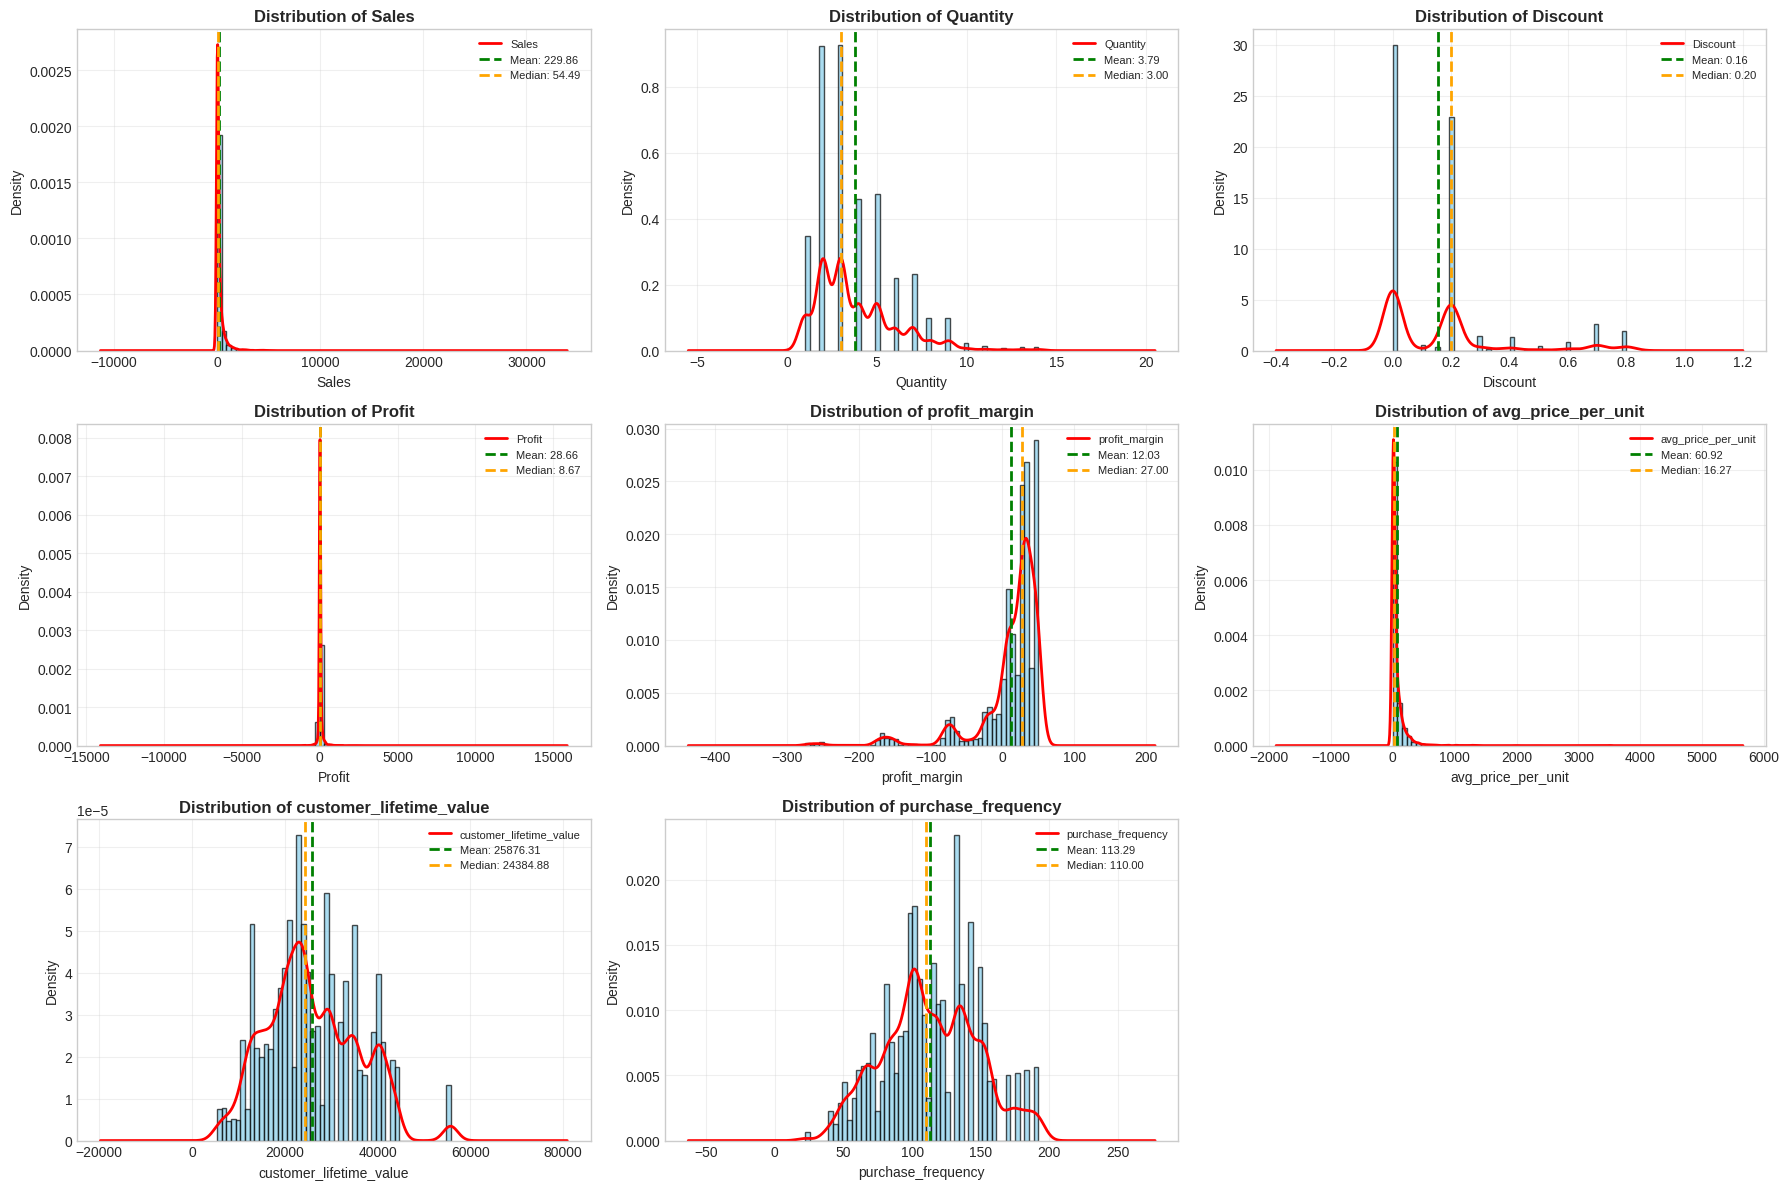

✅ Numerical distributions visualized and saved as 'univariate_numerical.png'

SUMMARY STATISTICS


,count,mean,std,min,25%,50%,75%,max
Sales,9994.00,229.86,623.25,0.44,17.28,54.49,209.94,22638.48
Quantity,9994.00,3.79,2.23,1.00,2.00,3.00,5.00,14.00
Discount,9994.00,0.16,0.21,0.00,0.00,0.20,0.20,0.80
Profit,9994.00,28.66,234.26,-6599.98,1.73,8.67,29.36,8399.98
profit_margin,9994.00,12.03,46.68,-275.00,7.50,27.00,36.25,50.00
avg_price_per_unit,9994.00,60.92,142.93,0.34,5.47,16.27,63.94,3773.08
customer_lifetime_value,9994.00,25876.31,9869.69,5402.90,18886.15,24384.88,32993.05,55719.21
purchase_frequency,9994.00,113.29,34.60,22.00,90.00,110.00,137.00,192.00


In [10]:
# ============================================
# UNIVARIATE ANALYSIS - NUMERICAL VARIABLES
# ============================================

print("="*60)
print("UNIVARIATE ANALYSIS - NUMERICAL VARIABLES")
print("="*60)

numerical_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 
                  'profit_margin', 'avg_price_per_unit', 
                  'customer_lifetime_value', 'purchase_frequency']

# Filter only existing columns
numerical_cols = [col for col in numerical_cols if col in df_clean.columns]

# Create subplots
n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*4))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    # Histogram with KDE
    axes[idx].hist(df_clean[col].dropna(), bins=50, edgecolor='black', 
                   alpha=0.7, color='skyblue', density=True)
    
    # Add KDE line
    df_clean[col].dropna().plot(kind='kde', ax=axes[idx], 
                                 color='red', linewidth=2, secondary_y=False)
    
    # Add mean and median lines
    mean_val = df_clean[col].mean()
    median_val = df_clean[col].median()
    
    axes[idx].axvline(mean_val, color='green', linestyle='--', 
                      linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[idx].axvline(median_val, color='orange', linestyle='--', 
                      linewidth=2, label=f'Median: {median_val:.2f}')
    
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Density', fontsize=10)
    axes[idx].legend(fontsize=8)
    axes[idx].grid(alpha=0.3)

# Remove empty subplots
for idx in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('univariate_numerical.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Numerical distributions visualized and saved as 'univariate_numerical.png'")

# Print summary statistics
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
display(df_clean[numerical_cols].describe().T)

UNIVARIATE ANALYSIS - CATEGORICAL VARIABLES

ANALYZING: Region


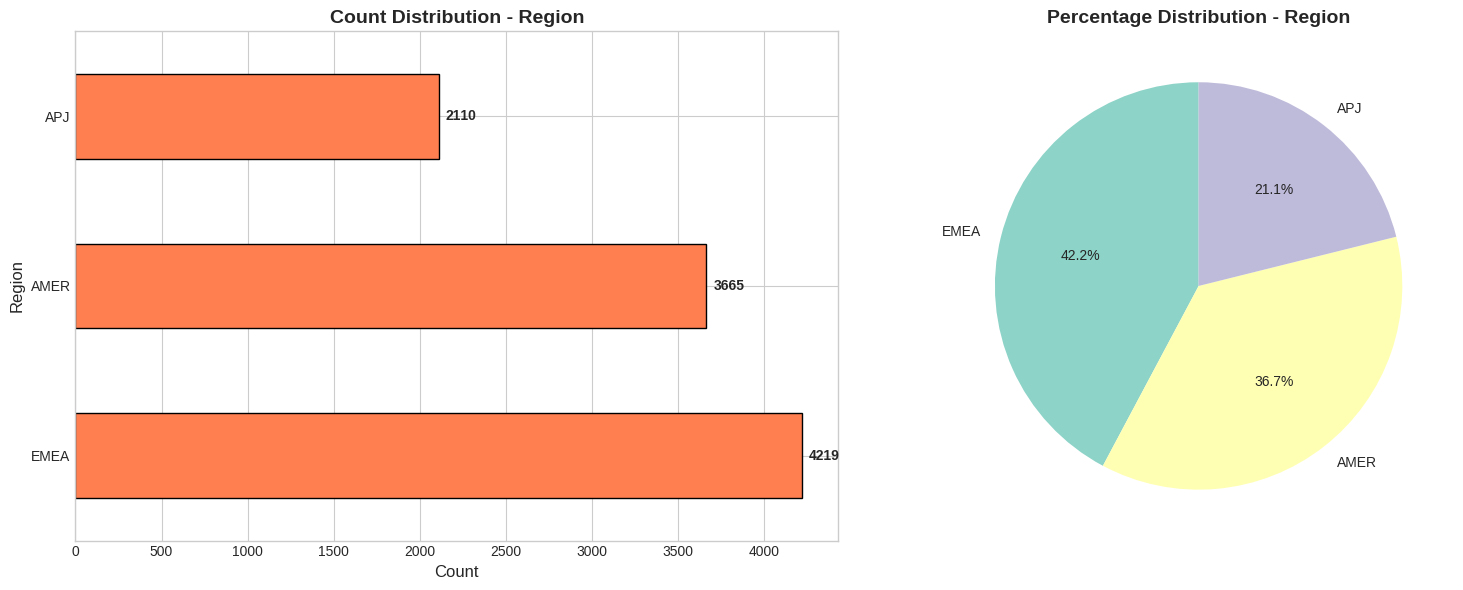


Unique values: 3

Top 10 Region:
Region
EMEA    4219
AMER    3665
APJ     2110
Name: count, dtype: int64

Percentage distribution (Top 10):
Region
EMEA   42.22
AMER   36.67
APJ    21.11
Name: count, dtype: float64

ANALYZING: Segment


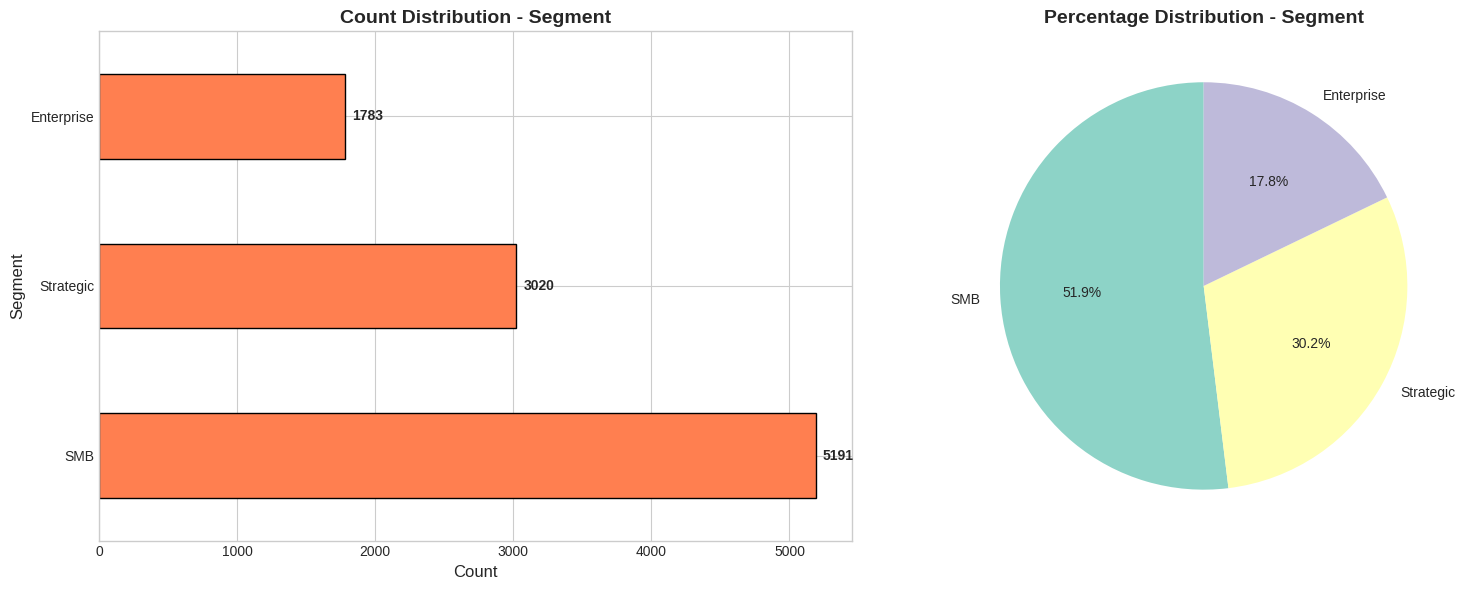


Unique values: 3

Top 10 Segment:
Segment
SMB           5191
Strategic     3020
Enterprise    1783
Name: count, dtype: int64

Percentage distribution (Top 10):
Segment
SMB          51.94
Strategic    30.22
Enterprise   17.84
Name: count, dtype: float64

ANALYZING: Industry


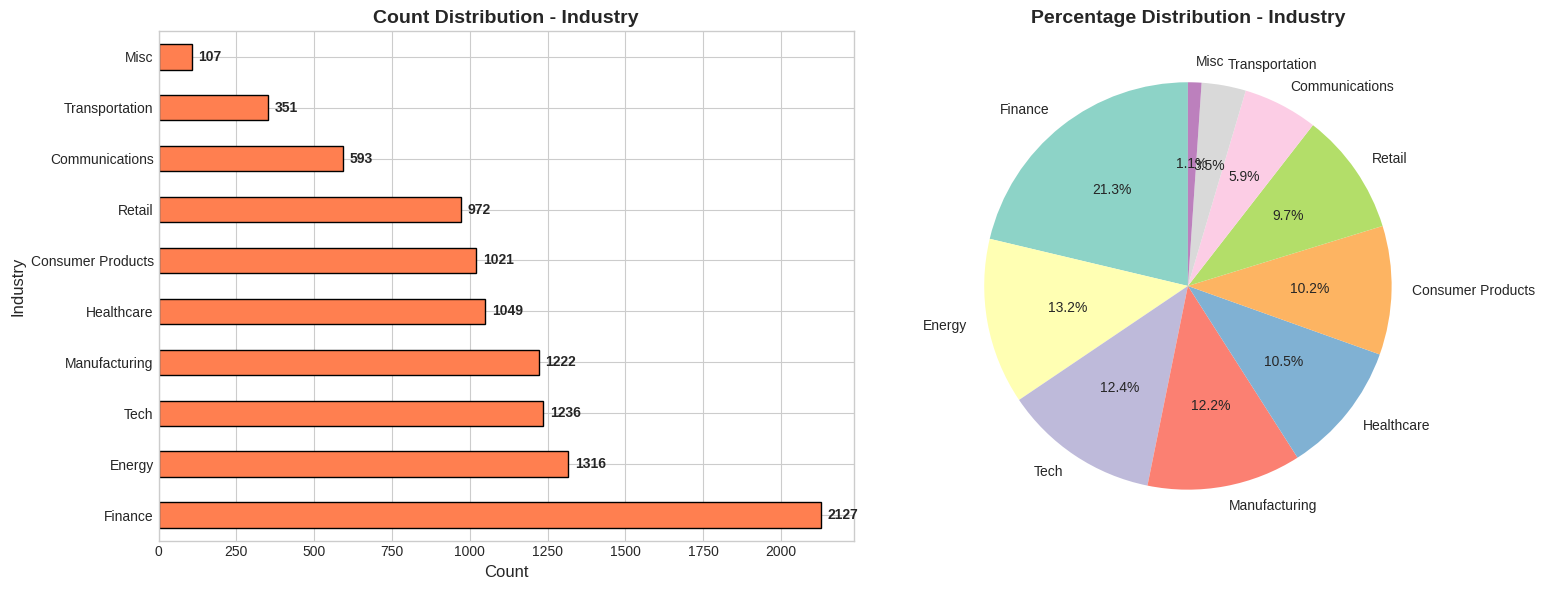


Unique values: 10

Top 10 Industry:
Industry
Finance              2127
Energy               1316
Tech                 1236
Manufacturing        1222
Healthcare           1049
Consumer Products    1021
Retail                972
Communications        593
Transportation        351
Misc                  107
Name: count, dtype: int64

Percentage distribution (Top 10):
Industry
Finance             21.28
Energy              13.17
Tech                12.37
Manufacturing       12.23
Healthcare          10.50
Consumer Products   10.22
Retail               9.73
Communications       5.93
Transportation       3.51
Misc                 1.07
Name: count, dtype: float64

ANALYZING: Product


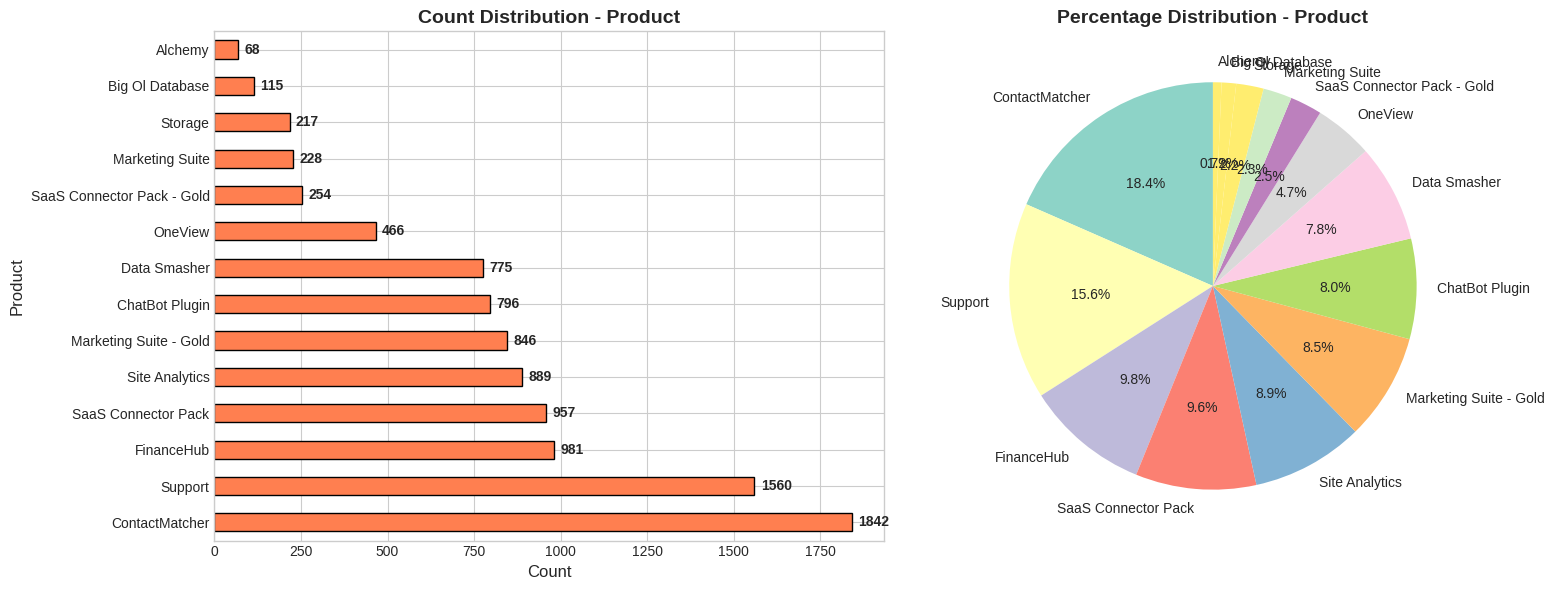


Unique values: 14

Top 10 Product:
Product
ContactMatcher                1842
Support                       1560
FinanceHub                     981
SaaS Connector Pack            957
Site Analytics                 889
Marketing Suite - Gold         846
ChatBot Plugin                 796
Data Smasher                   775
OneView                        466
SaaS Connector Pack - Gold     254
Name: count, dtype: int64

Percentage distribution (Top 10):
Product
ContactMatcher               18.43
Support                      15.61
FinanceHub                    9.82
SaaS Connector Pack           9.58
Site Analytics                8.90
Marketing Suite - Gold        8.47
ChatBot Plugin                7.96
Data Smasher                  7.75
OneView                       4.66
SaaS Connector Pack - Gold    2.54
Name: count, dtype: float64

ANALYZING: discount_category


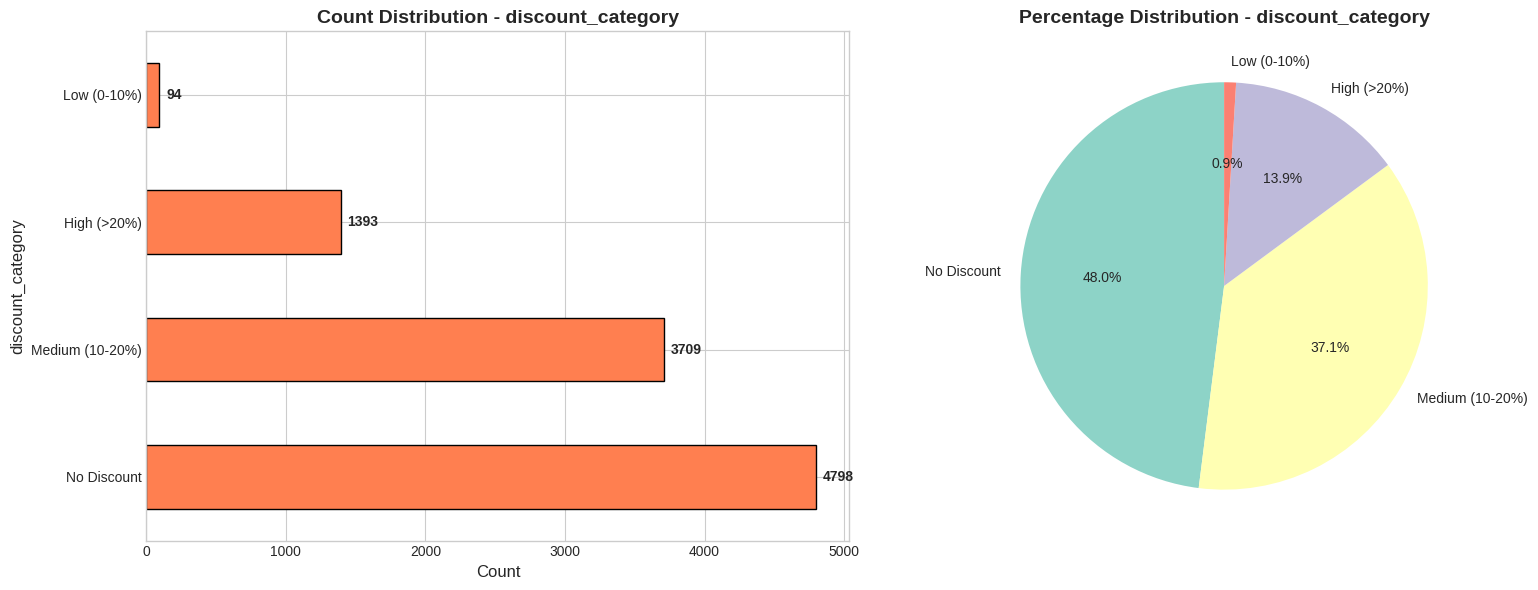


Unique values: 4

Top 10 discount_category:
discount_category
No Discount        4798
Medium (10-20%)    3709
High (>20%)        1393
Low (0-10%)          94
Name: count, dtype: int64

Percentage distribution (Top 10):
discount_category
No Discount       48.01
Medium (10-20%)   37.11
High (>20%)       13.94
Low (0-10%)        0.94
Name: count, dtype: float64

ANALYZING: deal_size


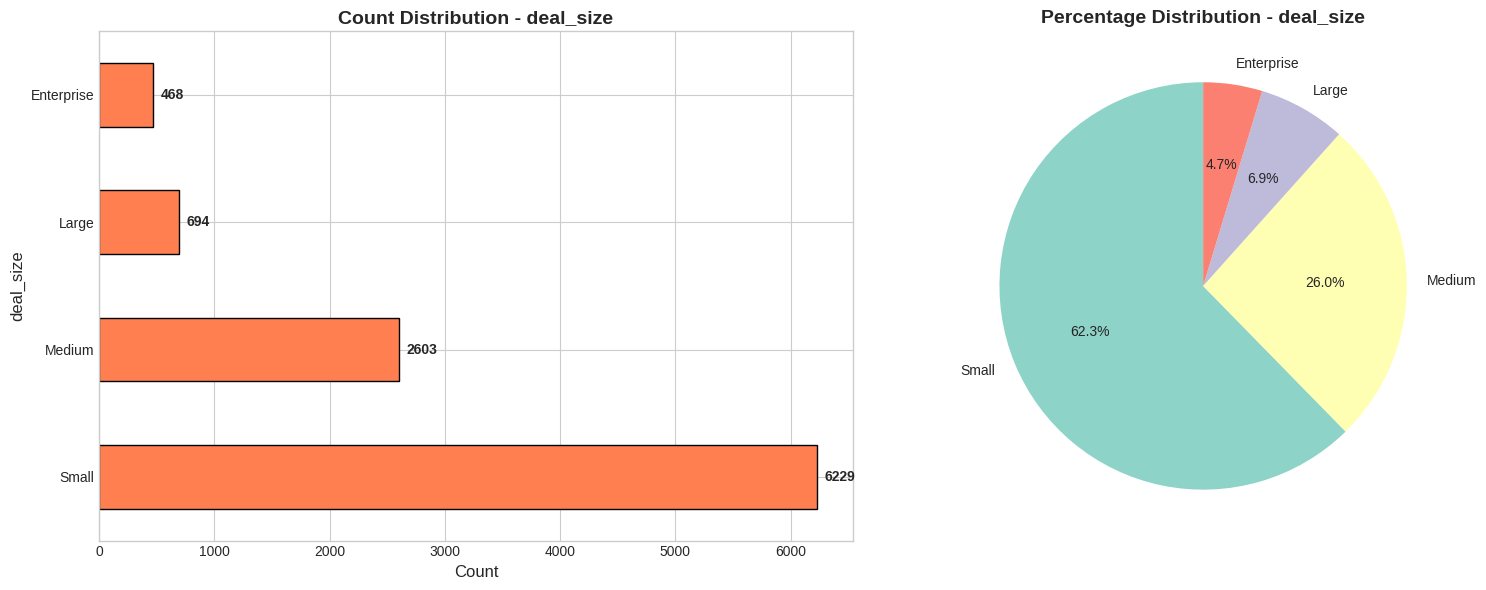


Unique values: 4

Top 10 deal_size:
deal_size
Small         6229
Medium        2603
Large          694
Enterprise     468
Name: count, dtype: int64

Percentage distribution (Top 10):
deal_size
Small        62.33
Medium       26.05
Large         6.94
Enterprise    4.68
Name: count, dtype: float64

ANALYZING: Country


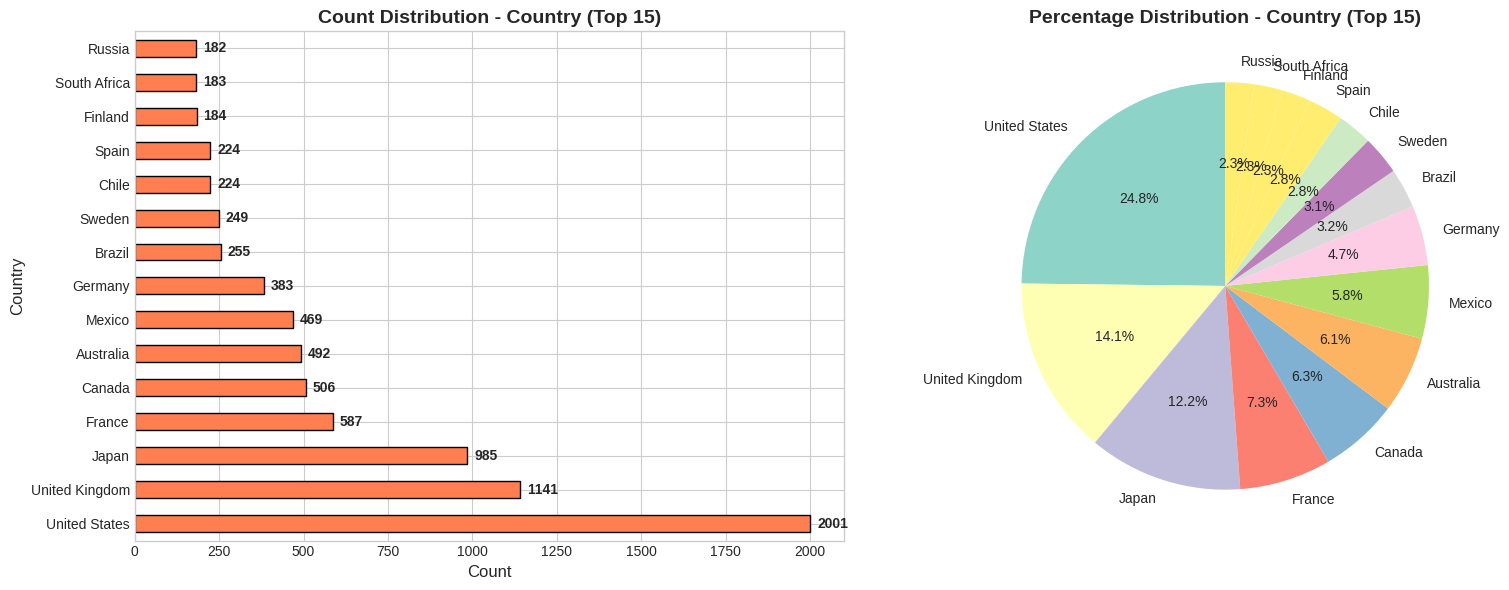


Unique values: 48

Top 10 Country:
Country
United States     2001
United Kingdom    1141
Japan              985
France             587
Canada             506
Australia          492
Mexico             469
Germany            383
Brazil             255
Sweden             249
Name: count, dtype: int64

Percentage distribution (Top 10):
Country
United States    20.02
United Kingdom   11.42
Japan             9.86
France            5.87
Canada            5.06
Australia         4.92
Mexico            4.69
Germany           3.83
Brazil            2.55
Sweden            2.49
Name: count, dtype: float64

✅ All categorical distributions visualized!


In [11]:
# ============================================
# UNIVARIATE ANALYSIS - CATEGORICAL VARIABLES
# ============================================

print("="*60)
print("UNIVARIATE ANALYSIS - CATEGORICAL VARIABLES")
print("="*60)

categorical_cols = ['Region', 'Segment', 'Industry', 'Product', 
                    'discount_category', 'deal_size', 'Country']

# Filter only existing columns
categorical_cols = [col for col in categorical_cols if col in df_clean.columns]

for col in categorical_cols:
    print(f"\n{'='*60}")
    print(f"ANALYZING: {col}")
    print("="*60)
    
    value_counts = df_clean[col].value_counts()
    
    # If too many categories, show top 15
    if len(value_counts) > 15:
        value_counts_plot = value_counts.head(15)
        title_suffix = " (Top 15)"
    else:
        value_counts_plot = value_counts
        title_suffix = ""
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Bar plot
    value_counts_plot.plot(kind='barh', ax=ax1, color='coral', edgecolor='black')
    ax1.set_title(f'Count Distribution - {col}{title_suffix}', 
                  fontsize=14, fontweight='bold')
    ax1.set_xlabel('Count', fontsize=12)
    ax1.set_ylabel(col, fontsize=12)
    
    # Add count labels
    for i, v in enumerate(value_counts_plot.values):
        ax1.text(v + max(value_counts_plot.values)*0.01, i, 
                str(v), va='center', fontsize=10, fontweight='bold')
    
    # Pie chart
    colors = plt.cm.Set3(range(len(value_counts_plot)))
    ax2.pie(value_counts_plot.values, labels=value_counts_plot.index, 
            autopct='%1.1f%%', colors=colors, startangle=90)
    ax2.set_title(f'Percentage Distribution - {col}{title_suffix}', 
                  fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(f'categorical_{col}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print statistics
    print(f"\nUnique values: {df_clean[col].nunique()}")
    print(f"\nTop 10 {col}:")
    print(value_counts.head(10))
    print(f"\nPercentage distribution (Top 10):")
    print((value_counts.head(10) / len(df_clean) * 100).round(2))

print("\n✅ All categorical distributions visualized!")

CORRELATION ANALYSIS


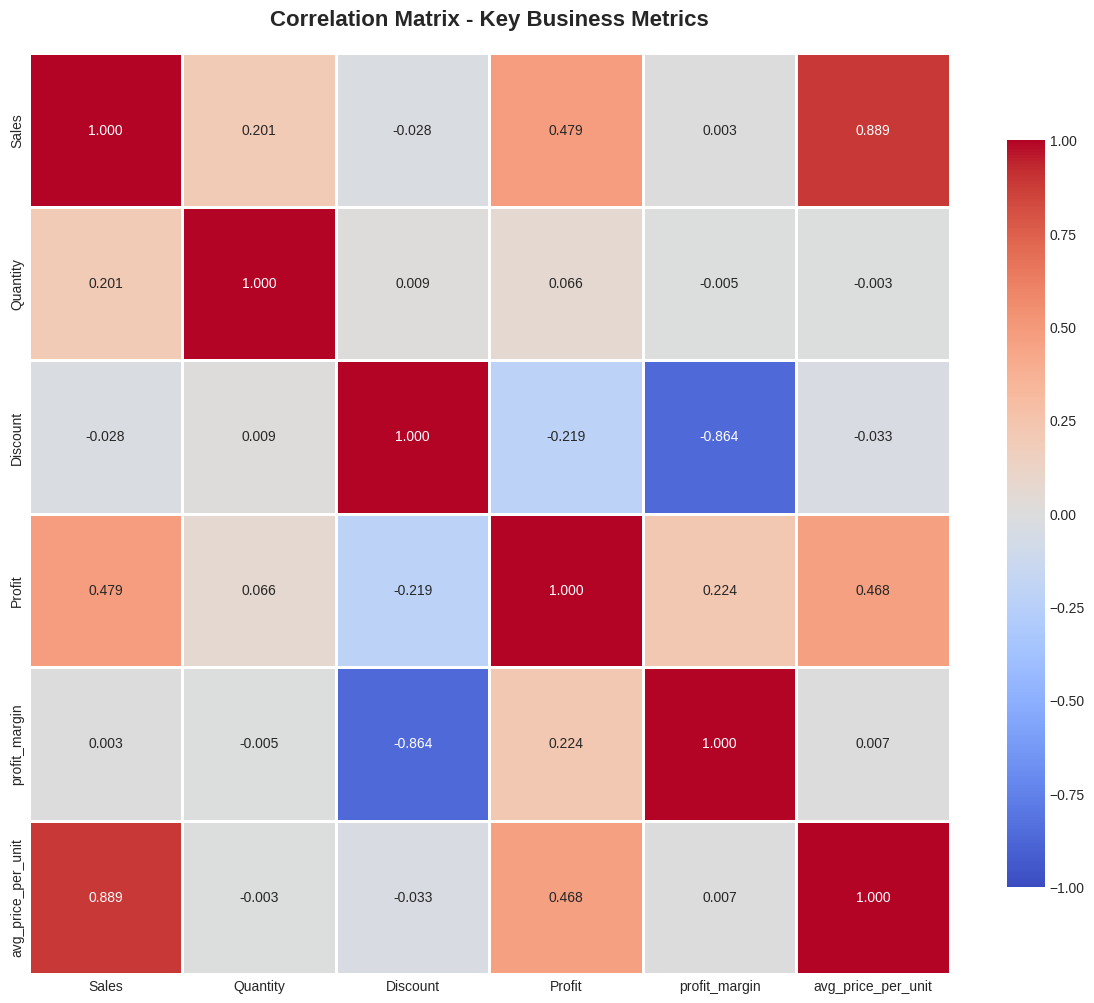

✅ Correlation heatmap saved as 'correlation_heatmap.png'

STRONGEST CORRELATIONS

🔺 Top 10 POSITIVE Correlations:
Sales               avg_price_per_unit   0.89
avg_price_per_unit  Sales                0.89
Sales               Profit               0.48
Profit              Sales                0.48
                    avg_price_per_unit   0.47
avg_price_per_unit  Profit               0.47
profit_margin       Profit               0.22
Profit              profit_margin        0.22
Quantity            Sales                0.20
Sales               Quantity             0.20
dtype: float64

🔻 Top 10 NEGATIVE Correlations:
profit_margin       Quantity             -0.01
Quantity            profit_margin        -0.01
Sales               Discount             -0.03
Discount            Sales                -0.03
                    avg_price_per_unit   -0.03
avg_price_per_unit  Discount             -0.03
Profit              Discount             -0.22
Discount            Profit               -0.22
  

In [12]:
# ============================================
# CORRELATION ANALYSIS
# ============================================

print("="*60)
print("CORRELATION ANALYSIS")
print("="*60)

# Select numerical columns for correlation
corr_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 
             'profit_margin', 'avg_price_per_unit']
corr_cols = [col for col in corr_cols if col in df_clean.columns]

# Calculate correlation matrix
correlation_matrix = df_clean[corr_cols].corr()

# Create figure
fig, ax = plt.subplots(figsize=(12, 10))

# Heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=2, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=ax)

ax.set_title('Correlation Matrix - Key Business Metrics', 
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Correlation heatmap saved as 'correlation_heatmap.png'")

# Print strongest correlations
print("\n" + "="*60)
print("STRONGEST CORRELATIONS")
print("="*60)

corr_pairs = correlation_matrix.unstack()
sorted_pairs = corr_pairs.sort_values(ascending=False)

# Remove self-correlations and duplicates
strong_corr = sorted_pairs[sorted_pairs < 0.999]

print("\n🔺 Top 10 POSITIVE Correlations:")
print(strong_corr.head(10))

print("\n🔻 Top 10 NEGATIVE Correlations:")
print(strong_corr.tail(10))

# Identify highly correlated pairs (>0.7 or <-0.7)
print("\n" + "="*60)
print("⚠️ HIGHLY CORRELATED PAIRS (|r| > 0.7)")
print("="*60)
high_corr = strong_corr[(strong_corr > 0.7) | (strong_corr < -0.7)]
if len(high_corr) > 0:
    for (col1, col2), corr in high_corr.items():
        print(f"{col1} ↔ {col2}: {corr:.3f}")
else:
    print("No highly correlated pairs found")

BIVARIATE ANALYSIS - KEY RELATIONSHIPS

1️⃣ Analyzing: Sales vs Profit


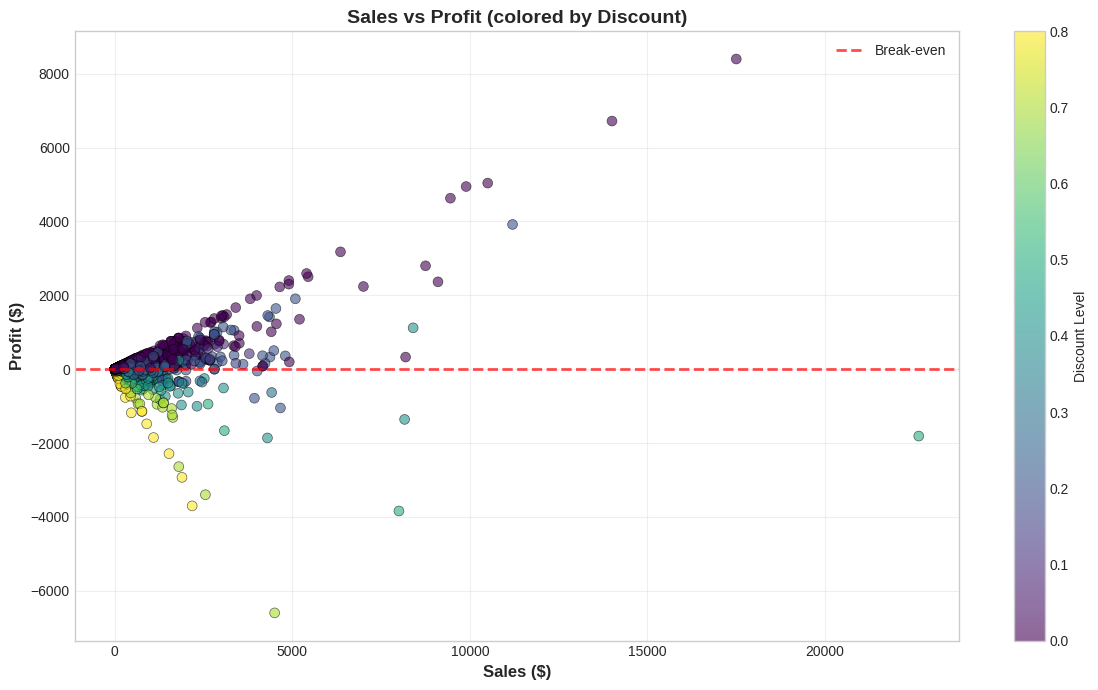


2️⃣ Analyzing: Discount vs Profit Margin


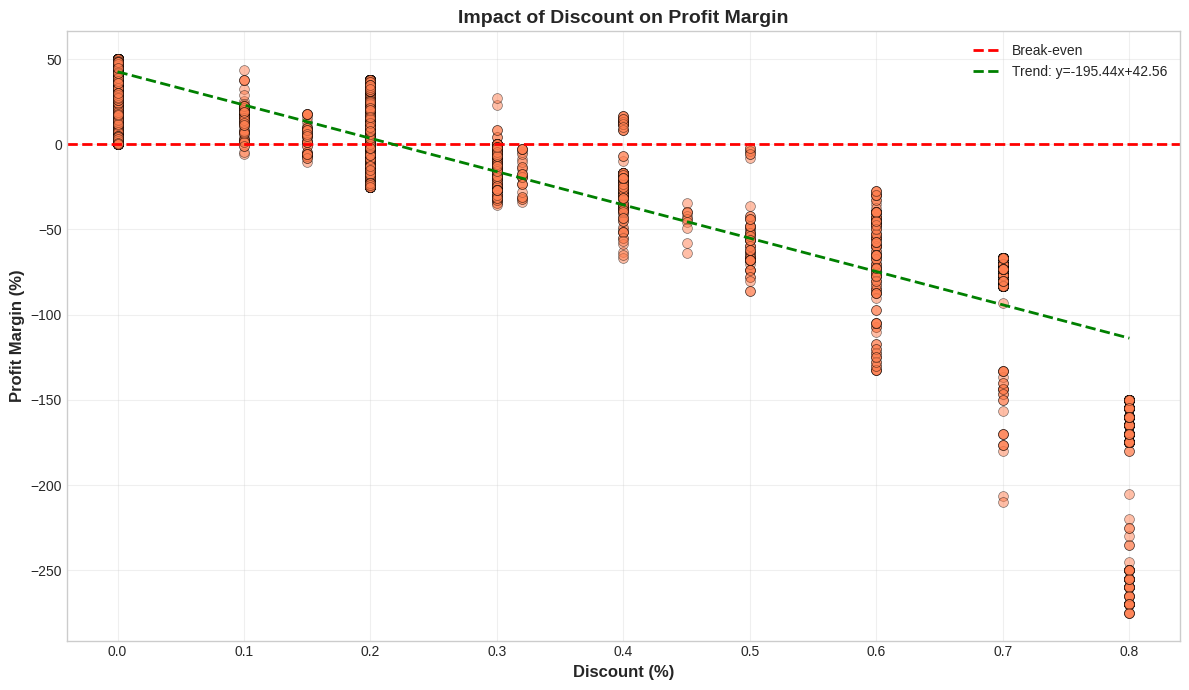


3️⃣ Analyzing: Customer Segment vs Sales


<Figure size 1200x700 with 0 Axes>

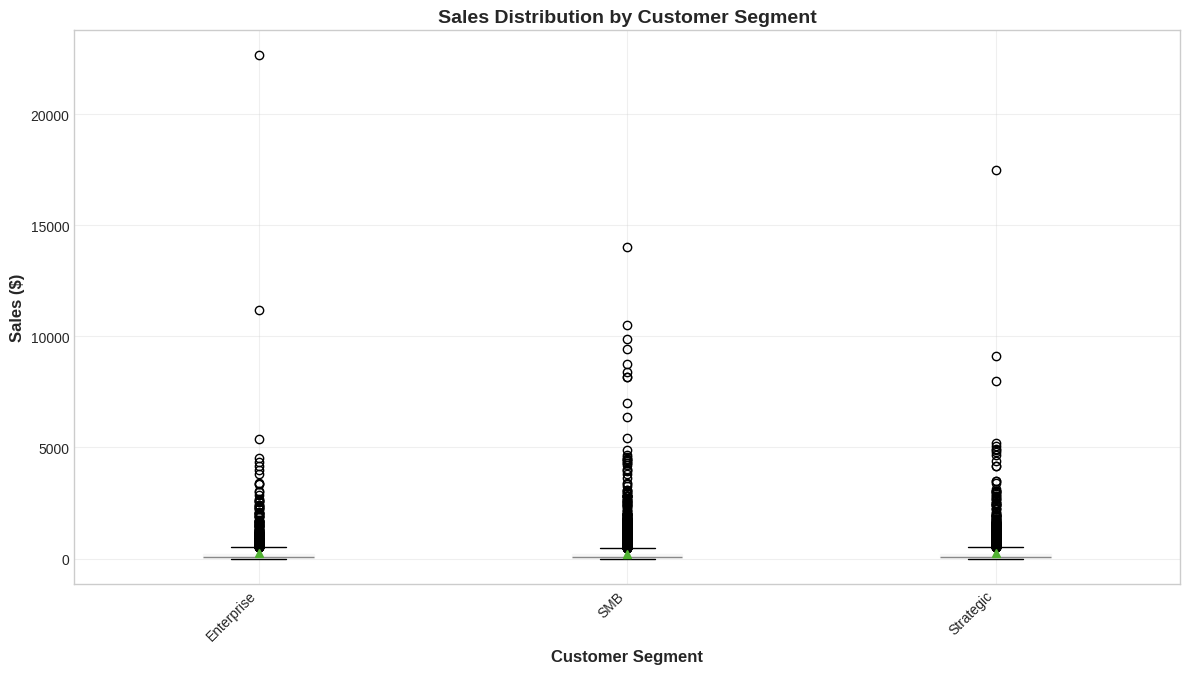


4️⃣ Analyzing: Industry vs Profit


<Figure size 1400x700 with 0 Axes>

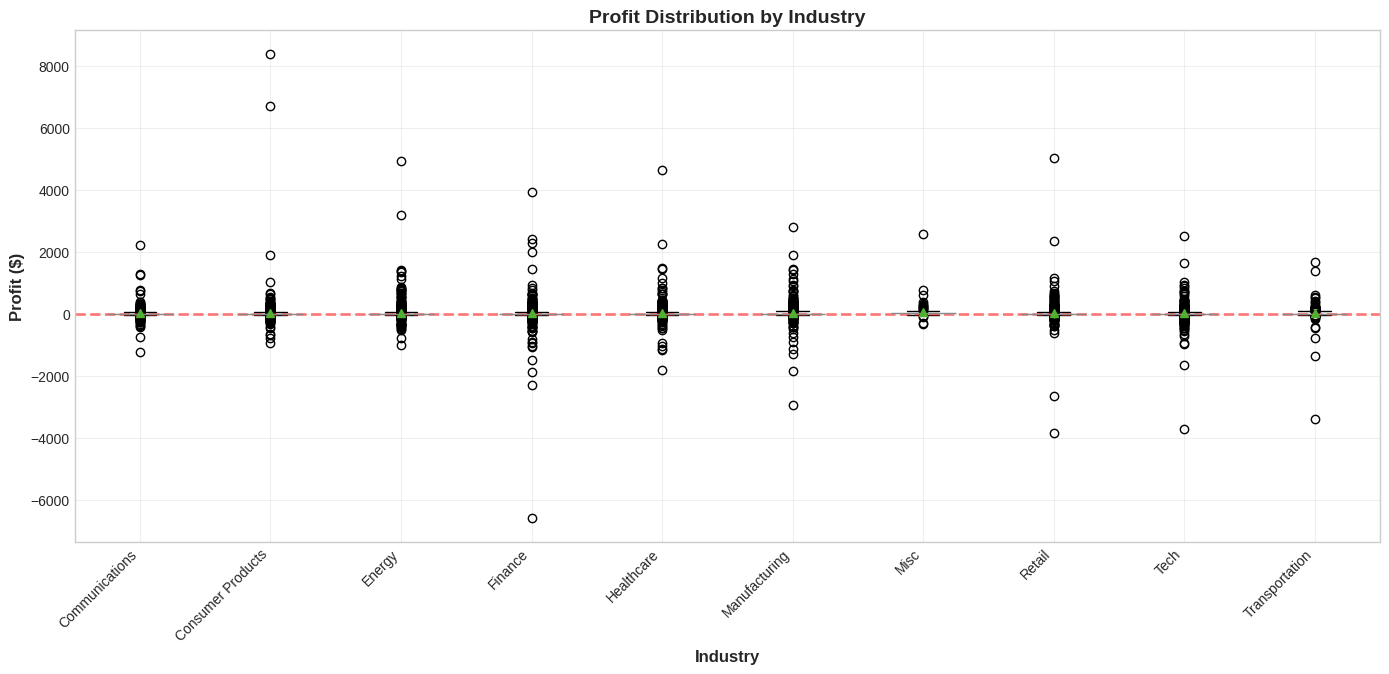


5️⃣ Analyzing: Region vs Sales


<Figure size 1200x700 with 0 Axes>

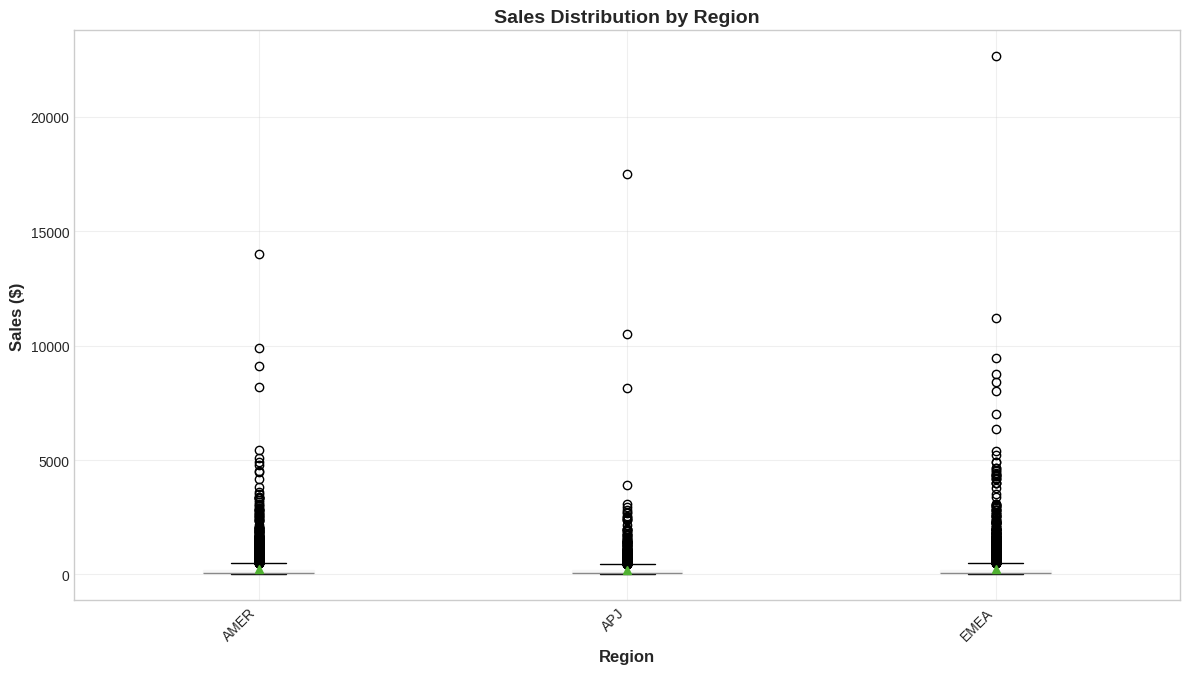


✅ All bivariate relationships visualized!


In [13]:
# ============================================
# BIVARIATE ANALYSIS - KEY RELATIONSHIPS
# ============================================

print("="*60)
print("BIVARIATE ANALYSIS - KEY RELATIONSHIPS")
print("="*60)

# 1. Sales vs Profit (colored by Discount)
print("\n1️⃣ Analyzing: Sales vs Profit")
plt.figure(figsize=(12, 7))
scatter = plt.scatter(df_clean['Sales'], df_clean['Profit'], 
                     c=df_clean['Discount'], cmap='viridis', 
                     alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, label='Discount Level')
plt.xlabel('Sales ($)', fontsize=12, fontweight='bold')
plt.ylabel('Profit ($)', fontsize=12, fontweight='bold')
plt.title('Sales vs Profit (colored by Discount)', fontsize=14, fontweight='bold')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Break-even')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('sales_vs_profit.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Discount vs Profit Margin
print("\n2️⃣ Analyzing: Discount vs Profit Margin")
plt.figure(figsize=(12, 7))
plt.scatter(df_clean['Discount'], df_clean['profit_margin'], 
           alpha=0.5, color='coral', s=50, edgecolors='black', linewidth=0.5)
plt.xlabel('Discount (%)', fontsize=12, fontweight='bold')
plt.ylabel('Profit Margin (%)', fontsize=12, fontweight='bold')
plt.title('Impact of Discount on Profit Margin', fontsize=14, fontweight='bold')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Break-even')

# Add regression line
z = np.polyfit(df_clean['Discount'], df_clean['profit_margin'], 1)
p = np.poly1d(z)
plt.plot(df_clean['Discount'].sort_values(), 
         p(df_clean['Discount'].sort_values()), 
         "g--", linewidth=2, label=f'Trend: y={z[0]:.2f}x+{z[1]:.2f}')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('discount_vs_margin.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Segment vs Sales (Boxplot)
print("\n3️⃣ Analyzing: Customer Segment vs Sales")
plt.figure(figsize=(12, 7))
df_clean.boxplot(column='Sales', by='Segment', figsize=(12, 7), 
                 patch_artist=True, showmeans=True)
plt.suptitle('')  # Remove default title
plt.title('Sales Distribution by Customer Segment', fontsize=14, fontweight='bold')
plt.ylabel('Sales ($)', fontsize=12, fontweight='bold')
plt.xlabel('Customer Segment', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('segment_vs_sales.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Industry vs Profit (Boxplot)
print("\n4️⃣ Analyzing: Industry vs Profit")
plt.figure(figsize=(14, 7))
df_clean.boxplot(column='Profit', by='Industry', figsize=(14, 7),
                 patch_artist=True, showmeans=True)
plt.suptitle('')
plt.title('Profit Distribution by Industry', fontsize=14, fontweight='bold')
plt.ylabel('Profit ($)', fontsize=12, fontweight='bold')
plt.xlabel('Industry', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.5)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('industry_vs_profit.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Region vs Sales (Boxplot)
print("\n5️⃣ Analyzing: Region vs Sales")
plt.figure(figsize=(12, 7))
df_clean.boxplot(column='Sales', by='Region', figsize=(12, 7),
                 patch_artist=True, showmeans=True)
plt.suptitle('')
plt.title('Sales Distribution by Region', fontsize=14, fontweight='bold')
plt.ylabel('Sales ($)', fontsize=12, fontweight='bold')
plt.xlabel('Region', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('region_vs_sales.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ All bivariate relationships visualized!")

MULTIVARIATE ANALYSIS

1️⃣ Creating pairplot (this may take 1-2 minutes)...


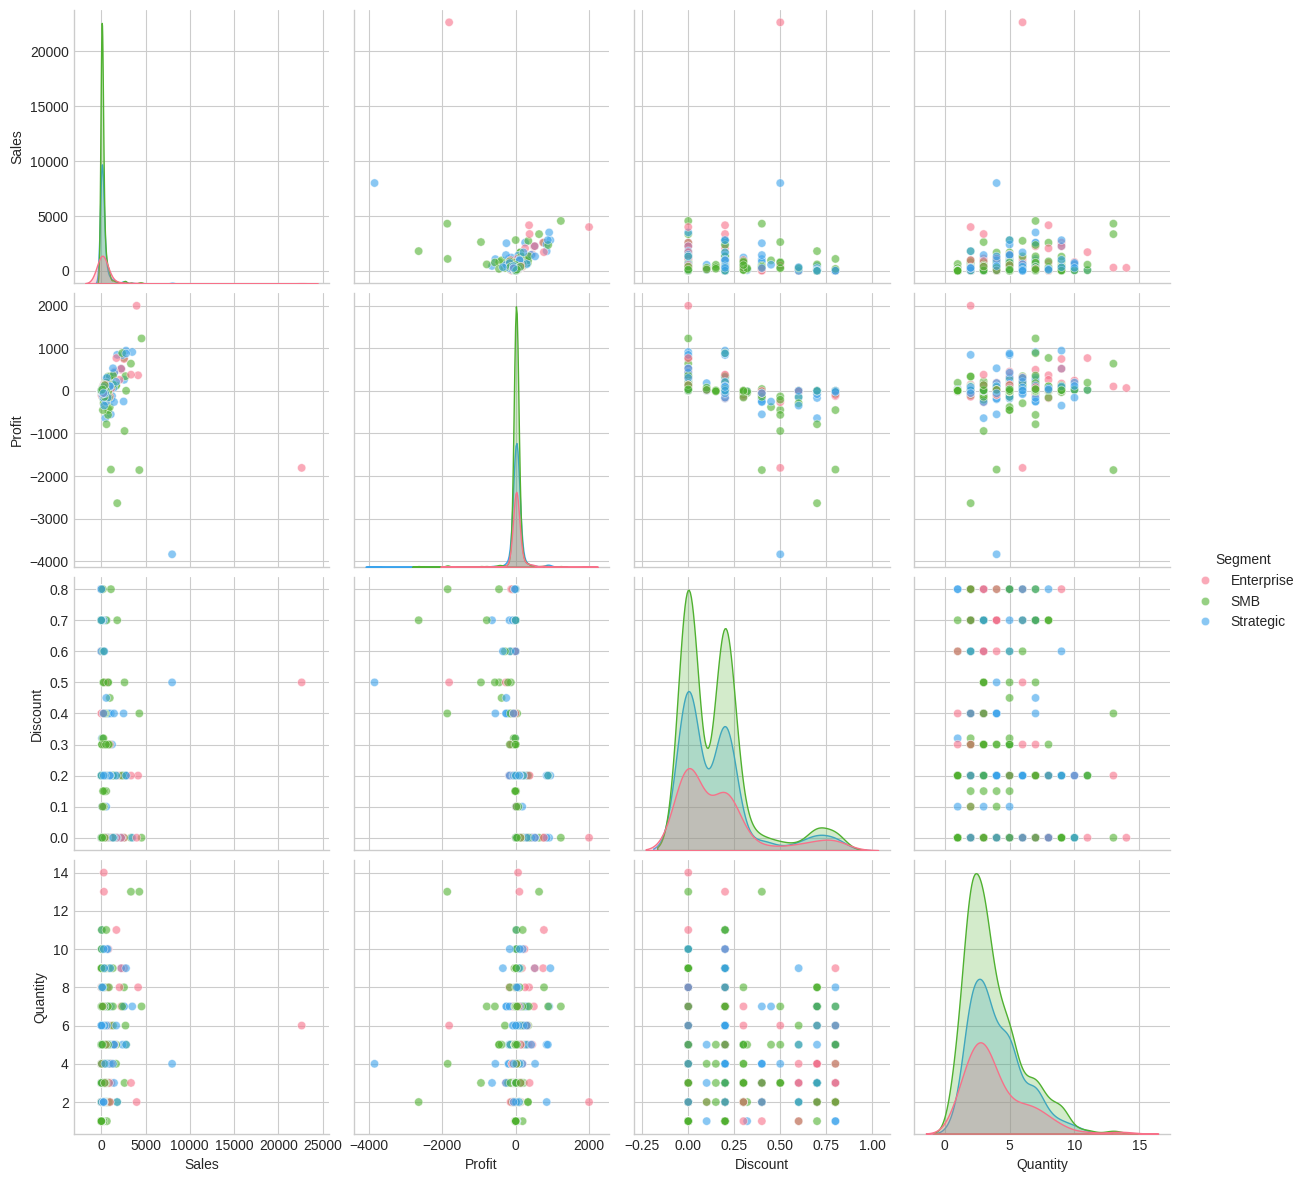

✅ Pairplot saved as 'pairplot.png'

2️⃣ Creating Region × Segment heatmap...


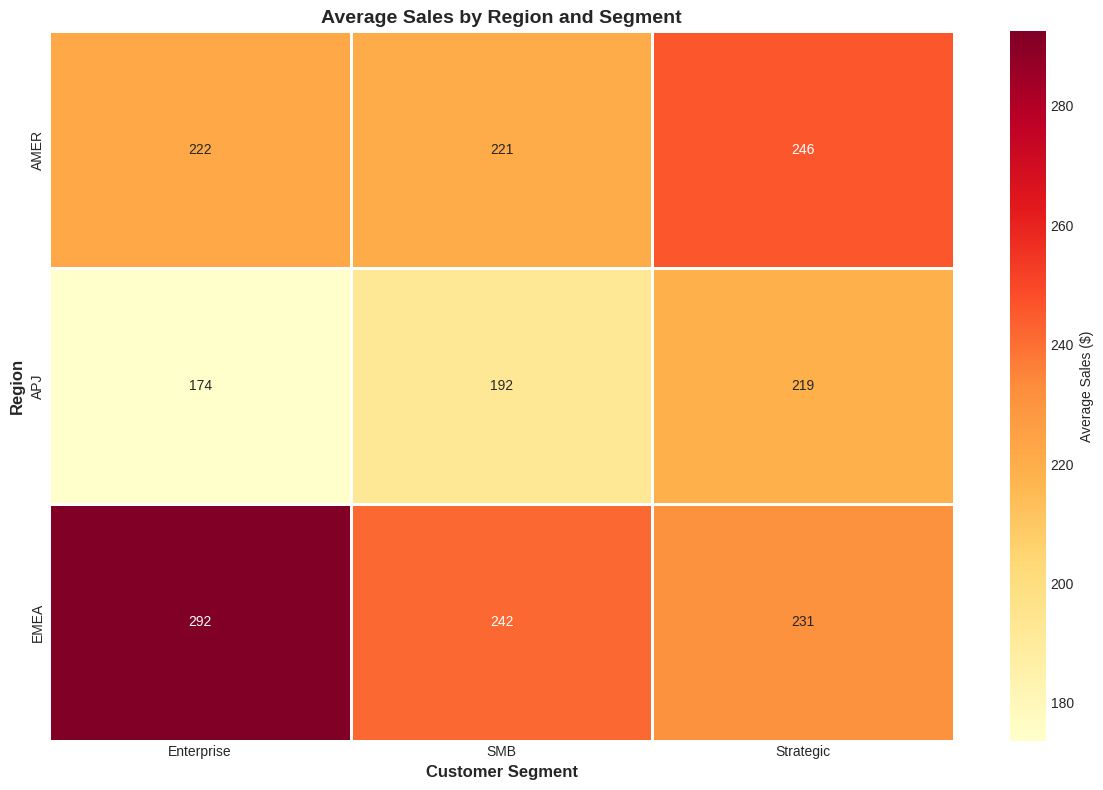

✅ Region × Segment heatmap saved

3️⃣ Creating Product × Industry heatmap...


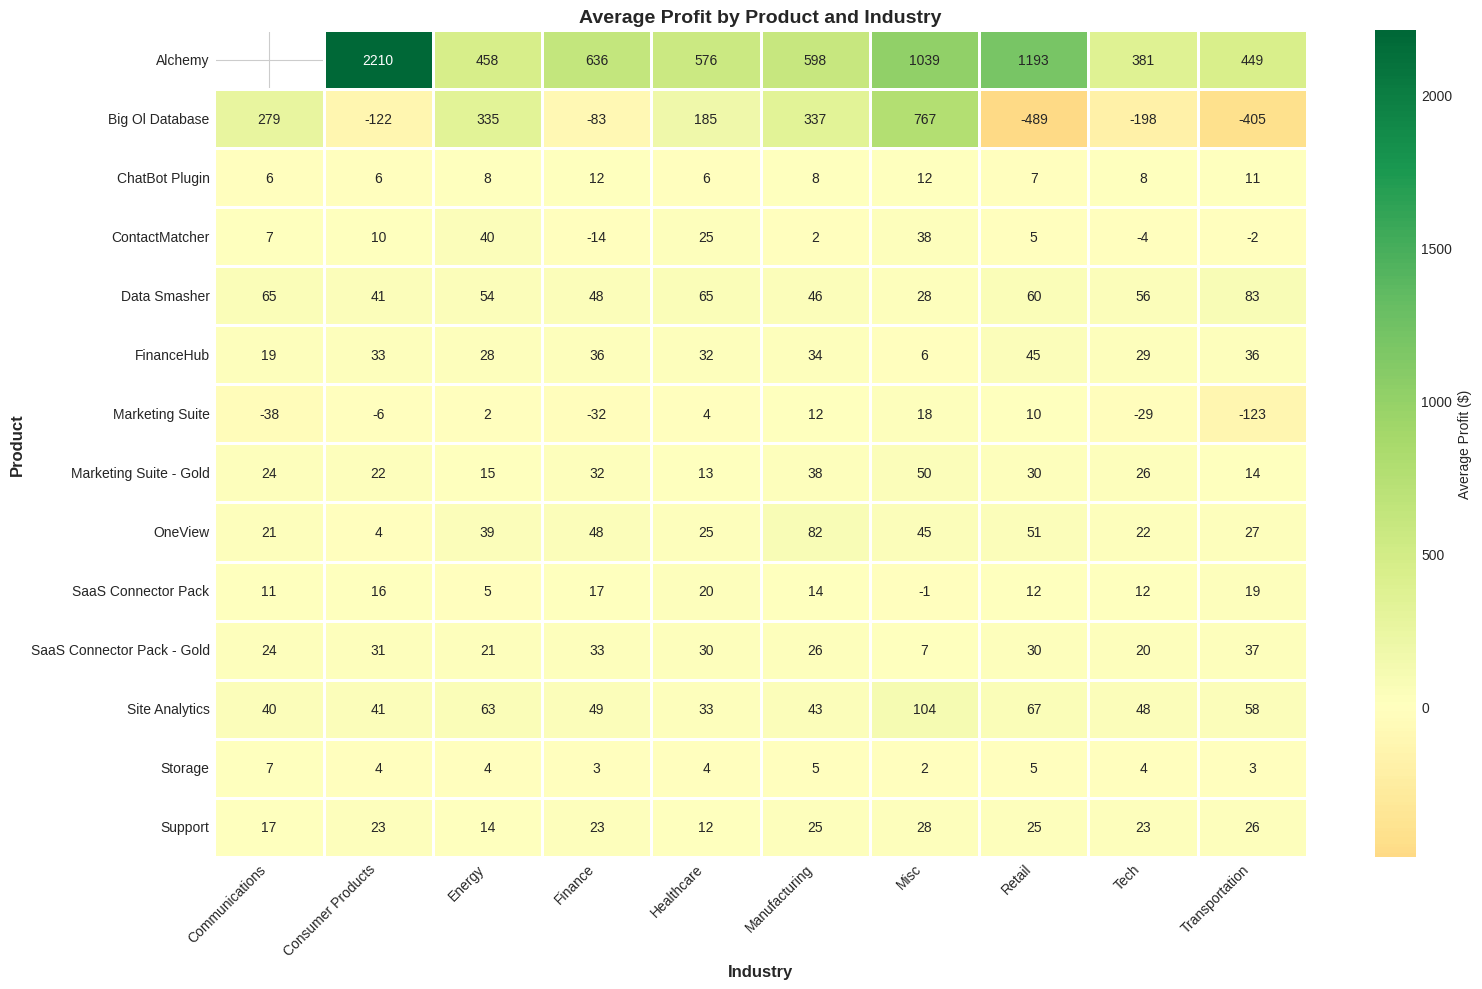

✅ Product × Industry heatmap saved

4️⃣ Analyzing discount impact across segments...


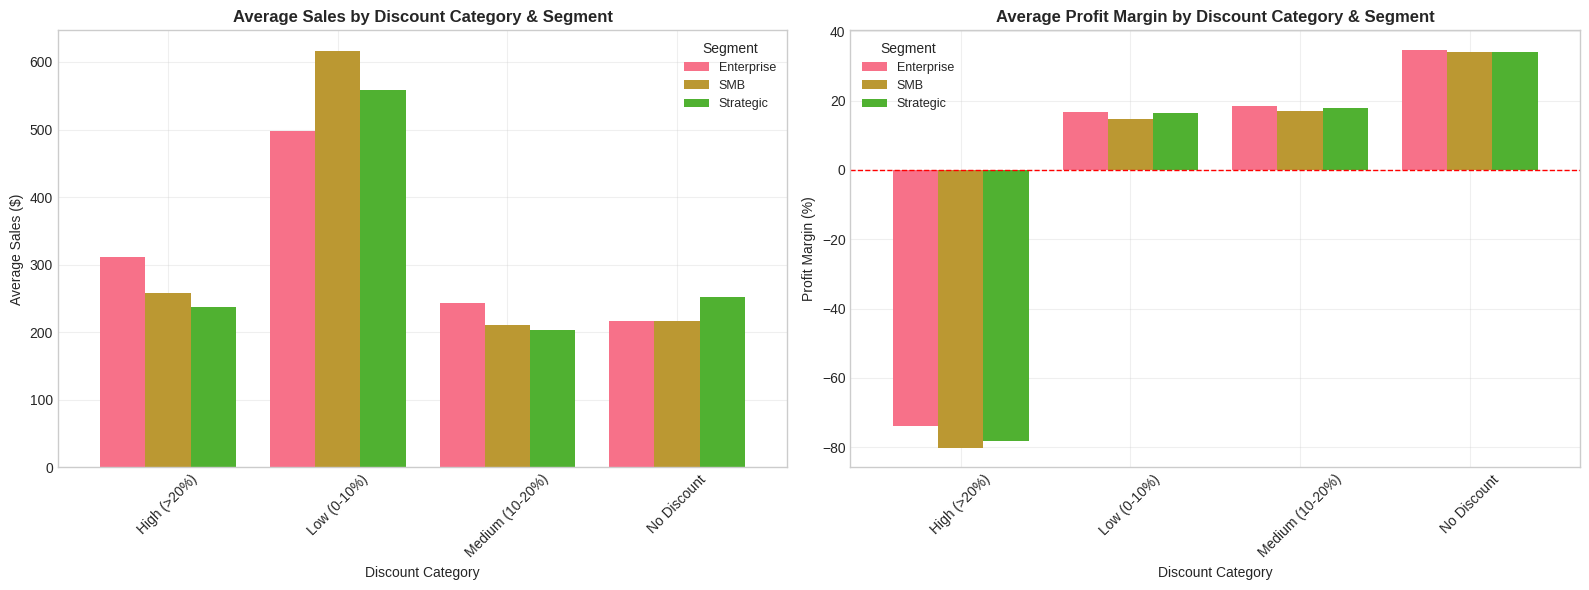

✅ Multivariate discount analysis saved

✅ MULTIVARIATE ANALYSIS COMPLETE!


In [14]:
# ============================================
# MULTIVARIATE ANALYSIS
# ============================================

print("="*60)
print("MULTIVARIATE ANALYSIS")
print("="*60)

# 1. Pairplot for key variables
print("\n1️⃣ Creating pairplot (this may take 1-2 minutes)...")

key_vars = ['Sales', 'Profit', 'Discount', 'Quantity', 'Segment']
key_vars = [col for col in key_vars if col in df_clean.columns]

# Sample data for faster plotting (1000 random rows)
sample_size = min(1000, len(df_clean))
pairplot_data = df_clean[key_vars].sample(sample_size, random_state=42)

sns.pairplot(pairplot_data, hue='Segment' if 'Segment' in key_vars else None, 
             diag_kind='kde', plot_kws={'alpha': 0.6}, height=3,
             palette='husl')
plt.savefig('pairplot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Pairplot saved as 'pairplot.png'")

# 2. Pivot Table - Region × Segment (Sales)
print("\n2️⃣ Creating Region × Segment heatmap...")

pivot_sales = df_clean.pivot_table(values='Sales', index='Region', 
                                     columns='Segment', aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_sales, annot=True, fmt='.0f', cmap='YlOrRd', 
            linewidths=1, cbar_kws={'label': 'Average Sales ($)'})
plt.title('Average Sales by Region and Segment', fontsize=14, fontweight='bold')
plt.xlabel('Customer Segment', fontsize=12, fontweight='bold')
plt.ylabel('Region', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('region_segment_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Region × Segment heatmap saved")

# 3. Product × Industry Analysis (Profit)
print("\n3️⃣ Creating Product × Industry heatmap...")

pivot_profit = df_clean.pivot_table(values='Profit', index='Product', 
                                      columns='Industry', aggfunc='mean')

plt.figure(figsize=(16, 10))
sns.heatmap(pivot_profit, annot=True, fmt='.0f', cmap='RdYlGn', 
            center=0, linewidths=1, cbar_kws={'label': 'Average Profit ($)'})
plt.title('Average Profit by Product and Industry', fontsize=14, fontweight='bold')
plt.xlabel('Industry', fontsize=12, fontweight='bold')
plt.ylabel('Product', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('product_industry_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Product × Industry heatmap saved")

# 4. Discount Category Impact
print("\n4️⃣ Analyzing discount impact across segments...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Average Sales by Discount Category and Segment
pivot_discount_sales = df_clean.pivot_table(values='Sales', 
                                             index='discount_category', 
                                             columns='Segment', aggfunc='mean')
pivot_discount_sales.plot(kind='bar', ax=axes[0], width=0.8)
axes[0].set_title('Average Sales by Discount Category & Segment', 
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average Sales ($)', fontsize=10)
axes[0].set_xlabel('Discount Category', fontsize=10)
axes[0].legend(title='Segment', fontsize=9)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3)

# Average Profit Margin by Discount Category and Segment
pivot_discount_margin = df_clean.pivot_table(values='profit_margin', 
                                              index='discount_category', 
                                              columns='Segment', aggfunc='mean')
pivot_discount_margin.plot(kind='bar', ax=axes[1], width=0.8)
axes[1].set_title('Average Profit Margin by Discount Category & Segment', 
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Profit Margin (%)', fontsize=10)
axes[1].set_xlabel('Discount Category', fontsize=10)
axes[1].legend(title='Segment', fontsize=9)
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('discount_impact_multivariate.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Multivariate discount analysis saved")

print("\n" + "="*60)
print("✅ MULTIVARIATE ANALYSIS COMPLETE!")
print("="*60)

KEY BUSINESS INSIGHTS EXTRACTION

1️⃣ CUSTOMER SEGMENT PERFORMANCE


,Total_Sales,Avg_Sales,Transaction_Count,Total_Profit,Avg_Profit,Avg_Margin%,Avg_Discount
Segment,,,,,,,
SMB,1161401.34,223.73,5191,134119.21,25.84,11.20,0.16
Strategic,706146.37,233.82,3020,91979.13,30.46,12.12,0.16
Enterprise,429653.15,240.97,1783,60298.68,33.82,14.29,0.15


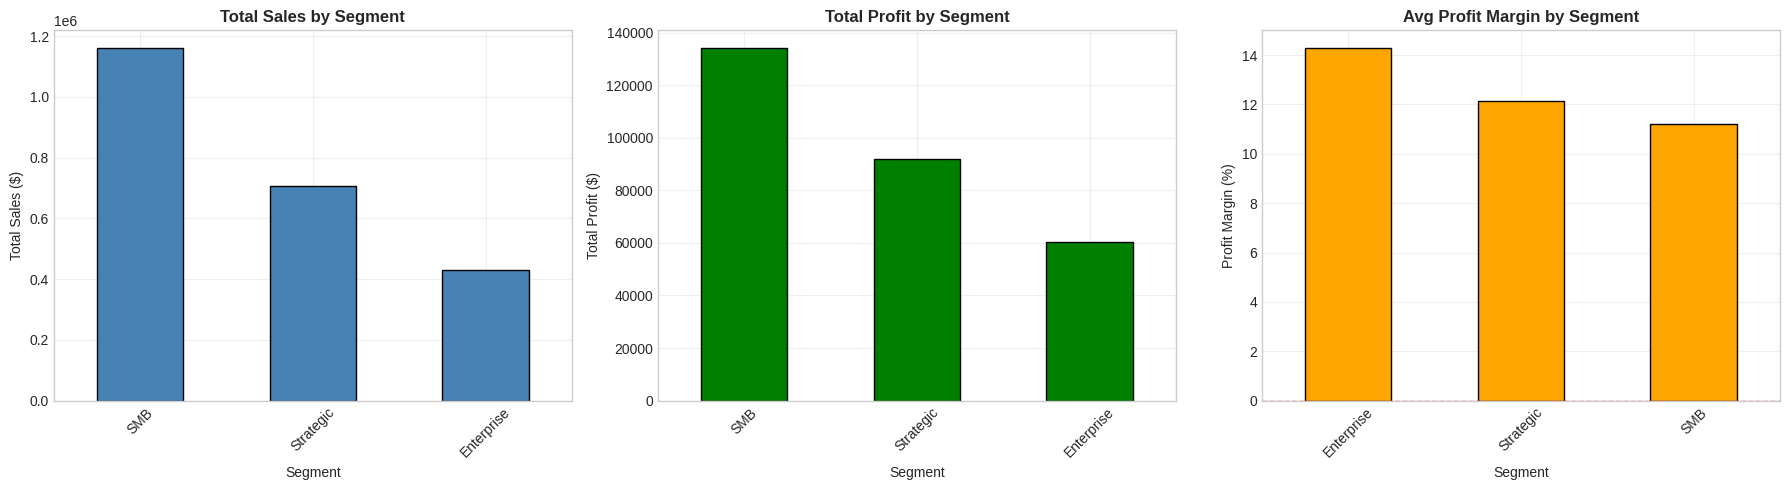


2️⃣ REGIONAL PERFORMANCE


,Total_Sales,Avg_Sales,Transaction_Count,Total_Profit,Avg_Profit,Avg_Margin%
Region,,,,,,
EMEA,1043887.02,247.43,4219,147456.05,34.95,17.00
AMER,837849.60,228.61,3665,127426.99,34.77,21.87
APJ,415464.24,196.90,2110,11513.99,5.46,-15.00


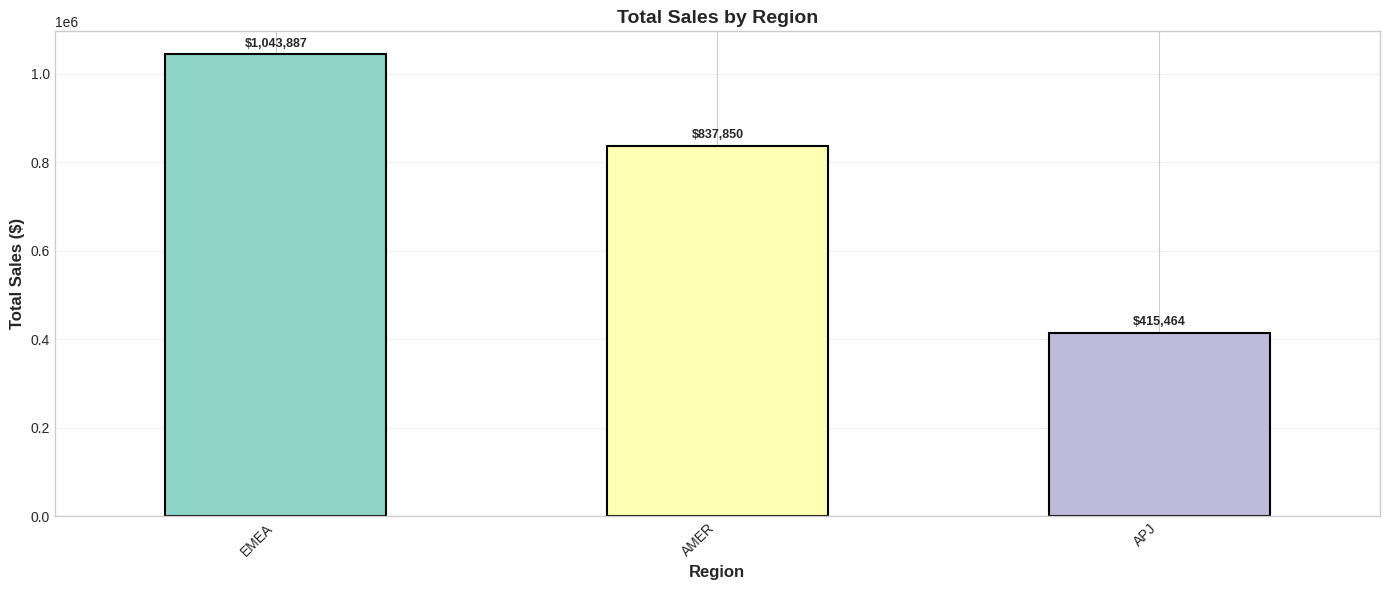


3️⃣ TOP 10 PRODUCTS BY SALES


,Total_Sales,Avg_Sales,Transaction_Count,Total_Profit,Avg_Profit,Avg_Margin%
Product,,,,,,
ContactMatcher,410378.26,222.79,1842,12496.28,6.78,-19.06
FinanceHub,340935.42,347.54,981,32136.42,32.76,18.70
Site Analytics,330007.05,371.21,889,44515.73,50.07,11.92
Marketing Suite - Gold,223843.61,264.59,846,21278.83,25.15,8.91
Big Ol Database,189238.63,1645.55,115,3384.76,29.43,-7.20
Data Smasher,167380.32,215.97,775,41936.64,54.11,21.82
Alchemy,149528.03,2198.94,68,55617.82,817.91,31.72
Support,125152.74,80.23,1560,32864.47,21.07,38.74
Marketing Suite,114880.00,503.86,228,-3472.56,-15.23,-12.66



4️⃣ INDUSTRY PERFORMANCE


,Total_Sales,Avg_Sales,Transaction_Count,Total_Profit,Avg_Profit,Avg_Margin%
Industry,,,,,,
Finance,474150.48,222.92,2127,50348.97,23.67,12.15
Energy,304644.14,231.49,1316,45282.31,34.41,11.91
Manufacturing,295192.38,241.56,1222,38413.11,31.43,13.33
Healthcare,273183.29,260.42,1049,31969.09,30.48,11.84
Tech,263169.03,212.92,1236,24615.04,19.92,11.95
Consumer Products,224044.14,219.44,1021,37018.01,36.26,10.50
Retail,223072.07,229.50,972,30207.82,31.08,13.25
Communications,120962.24,203.98,593,13976.34,23.57,11.23
Transportation,90191.33,256.96,351,7402.70,21.09,9.97



5️⃣ DISCOUNT IMPACT ANALYSIS


,Avg_Sales,Count,Avg_Profit,Avg_Margin%
discount_category,,,,
High (>20%),260.42,1393,-97.18,-78.45
Low (0-10%),578.40,94,96.06,15.58
Medium (10-20%),213.58,3709,24.74,17.48
No Discount,226.74,4798,66.90,34.02


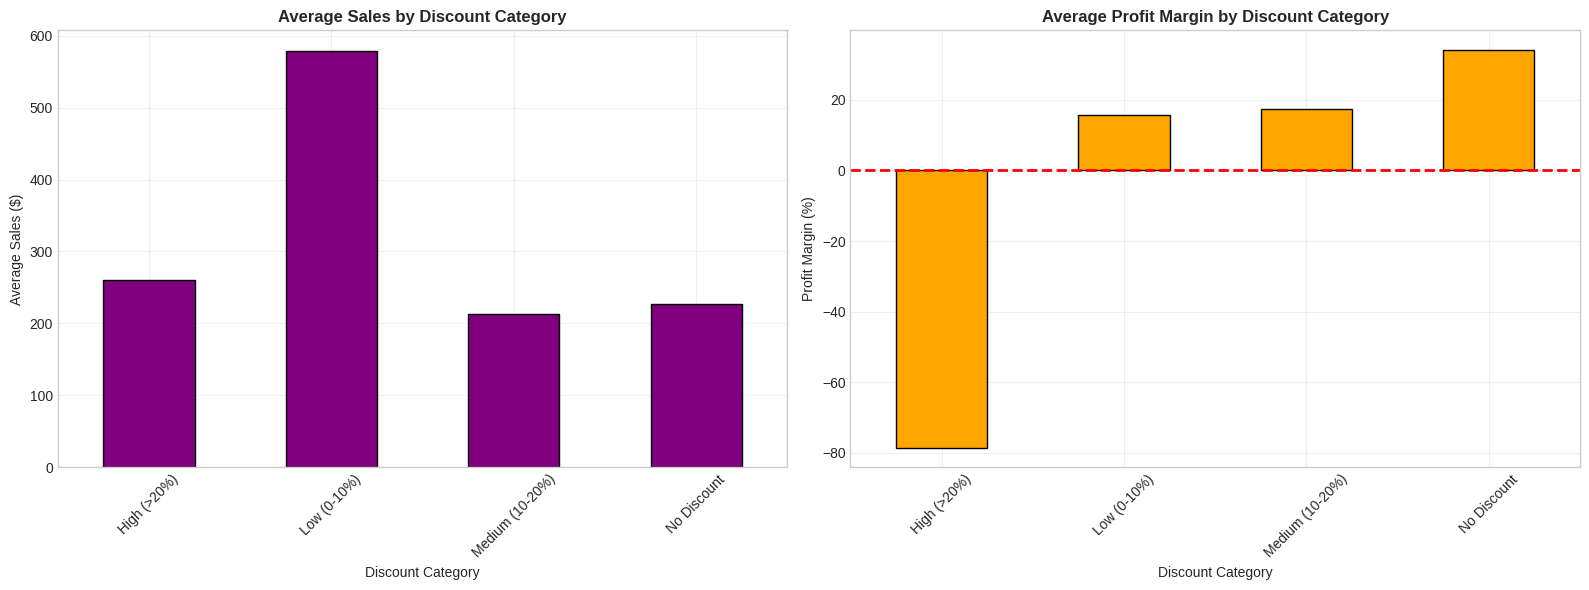


6️⃣ PROFITABILITY ANALYSIS
Profitable transactions: 8,058 (80.63%)
Unprofitable transactions: 1,936 (19.37%)

💰 OVERALL METRICS:
   Total Sales: $2,297,200.86
   Total Profit: $286,397.02
   Overall Profit Margin: 12.47%
   Average Deal Size: $229.86
   Median Deal Size: $54.49

7️⃣ TOP 10 CUSTOMERS BY LIFETIME VALUE


,customer_lifetime_value
Customer,
Anthem,55719.21
Ford Motor,43893.04
Allianz,42904.17
Bank of America Corp.,41255.95
Valero Energy,41220.42
Lowes,40360.16
Tyson Foods,40326.34
Allstate,39941.64
AmerisourceBergen,39234.76



✅ Business insights extraction complete!


In [15]:
# ============================================
# BUSINESS INSIGHTS ANALYSIS
# ============================================

print("="*60)
print("KEY BUSINESS INSIGHTS EXTRACTION")
print("="*60)

# 1. SEGMENT PERFORMANCE
print("\n" + "="*60)
print("1️⃣ CUSTOMER SEGMENT PERFORMANCE")
print("="*60)

segment_analysis = df_clean.groupby('Segment').agg({
    'Sales': ['sum', 'mean', 'count'],
    'Profit': ['sum', 'mean'],
    'profit_margin': 'mean',
    'Discount': 'mean'
}).round(2)

segment_analysis.columns = ['Total_Sales', 'Avg_Sales', 'Transaction_Count',
                            'Total_Profit', 'Avg_Profit', 'Avg_Margin%', 'Avg_Discount']

display(segment_analysis.sort_values('Total_Sales', ascending=False))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Total Sales by Segment
segment_sales = df_clean.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
segment_sales.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Total Sales by Segment', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Total Sales ($)', fontsize=10)
axes[0].set_xlabel('Segment', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3)

# Total Profit by Segment
segment_profit = df_clean.groupby('Segment')['Profit'].sum().sort_values(ascending=False)
segment_profit.plot(kind='bar', ax=axes[1], color='green', edgecolor='black')
axes[1].set_title('Total Profit by Segment', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Total Profit ($)', fontsize=10)
axes[1].set_xlabel('Segment', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(alpha=0.3)

# Avg Profit Margin by Segment
segment_margin = df_clean.groupby('Segment')['profit_margin'].mean().sort_values(ascending=False)
segment_margin.plot(kind='bar', ax=axes[2], color='orange', edgecolor='black')
axes[2].set_title('Avg Profit Margin by Segment', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Profit Margin (%)', fontsize=10)
axes[2].set_xlabel('Segment', fontsize=10)
axes[2].tick_params(axis='x', rotation=45)
axes[2].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('segment_performance.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. REGIONAL PERFORMANCE
print("\n" + "="*60)
print("2️⃣ REGIONAL PERFORMANCE")
print("="*60)

region_analysis = df_clean.groupby('Region').agg({
    'Sales': ['sum', 'mean', 'count'],
    'Profit': ['sum', 'mean'],
    'profit_margin': 'mean'
}).round(2)

region_analysis.columns = ['Total_Sales', 'Avg_Sales', 'Transaction_Count',
                           'Total_Profit', 'Avg_Profit', 'Avg_Margin%']

display(region_analysis.sort_values('Total_Sales', ascending=False))

# Visualization
plt.figure(figsize=(14, 6))
region_sales = df_clean.groupby('Region')['Sales'].sum().sort_values(ascending=False)
colors = plt.cm.Set3(range(len(region_sales)))
region_sales.plot(kind='bar', color=colors, edgecolor='black', linewidth=1.5)
plt.title('Total Sales by Region', fontsize=14, fontweight='bold')
plt.ylabel('Total Sales ($)', fontsize=12, fontweight='bold')
plt.xlabel('Region', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3, axis='y')

# Add value labels on bars
for i, v in enumerate(region_sales.values):
    plt.text(i, v + max(region_sales)*0.01, f'${v:,.0f}', 
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('region_performance.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. PRODUCT PERFORMANCE
print("\n" + "="*60)
print("3️⃣ TOP 10 PRODUCTS BY SALES")
print("="*60)

product_analysis = df_clean.groupby('Product').agg({
    'Sales': ['sum', 'mean', 'count'],
    'Profit': ['sum', 'mean'],
    'profit_margin': 'mean'
}).round(2)

product_analysis.columns = ['Total_Sales', 'Avg_Sales', 'Transaction_Count',
                            'Total_Profit', 'Avg_Profit', 'Avg_Margin%']

top_products = product_analysis.nlargest(10, 'Total_Sales')
display(top_products)

# 4. INDUSTRY PERFORMANCE
print("\n" + "="*60)
print("4️⃣ INDUSTRY PERFORMANCE")
print("="*60)

industry_analysis = df_clean.groupby('Industry').agg({
    'Sales': ['sum', 'mean', 'count'],
    'Profit': ['sum', 'mean'],
    'profit_margin': 'mean'
}).round(2)

industry_analysis.columns = ['Total_Sales', 'Avg_Sales', 'Transaction_Count',
                             'Total_Profit', 'Avg_Profit', 'Avg_Margin%']

display(industry_analysis.nlargest(10, 'Total_Sales'))

# 5. DISCOUNT IMPACT ANALYSIS
print("\n" + "="*60)
print("5️⃣ DISCOUNT IMPACT ANALYSIS")
print("="*60)

discount_impact = df_clean.groupby('discount_category').agg({
    'Sales': ['mean', 'count'],
    'Profit': 'mean',
    'profit_margin': 'mean'
}).round(2)

discount_impact.columns = ['Avg_Sales', 'Count', 'Avg_Profit', 'Avg_Margin%']
display(discount_impact)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

discount_impact['Avg_Sales'].plot(kind='bar', ax=axes[0], color='purple', edgecolor='black')
axes[0].set_title('Average Sales by Discount Category', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average Sales ($)', fontsize=10)
axes[0].set_xlabel('Discount Category', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3)

discount_impact['Avg_Margin%'].plot(kind='bar', ax=axes[1], color='orange', edgecolor='black')
axes[1].set_title('Average Profit Margin by Discount Category', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Profit Margin (%)', fontsize=10)
axes[1].set_xlabel('Discount Category', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('discount_impact.png', dpi=300, bbox_inches='tight')
plt.show()

# 6. PROFITABILITY ANALYSIS
print("\n" + "="*60)
print("6️⃣ PROFITABILITY ANALYSIS")
print("="*60)

profitable_count = df_clean['is_profitable'].sum()
total_count = len(df_clean)
profitable_pct = (profitable_count / total_count) * 100

print(f"Profitable transactions: {profitable_count:,} ({profitable_pct:.2f}%)")
print(f"Unprofitable transactions: {total_count - profitable_count:,} ({100-profitable_pct:.2f}%)")

total_sales = df_clean['Sales'].sum()
total_profit = df_clean['Profit'].sum()
overall_margin = (total_profit / total_sales) * 100

print(f"\n💰 OVERALL METRICS:")
print(f"   Total Sales: ${total_sales:,.2f}")
print(f"   Total Profit: ${total_profit:,.2f}")
print(f"   Overall Profit Margin: {overall_margin:.2f}%")
print(f"   Average Deal Size: ${df_clean['Sales'].mean():,.2f}")
print(f"   Median Deal Size: ${df_clean['Sales'].median():,.2f}")

# 7. TOP CUSTOMERS
print("\n" + "="*60)
print("7️⃣ TOP 10 CUSTOMERS BY LIFETIME VALUE")
print("="*60)

top_customers = df_clean.groupby('Customer')['customer_lifetime_value'].first().sort_values(ascending=False).head(10)
display(top_customers.to_frame())

print("\n✅ Business insights extraction complete!")

In [16]:
# ============================================
# SAVE KEY INSIGHTS TO FILE
# ============================================

insights_text = f"""
{"="*60}
AWS SAAS SALES DATA - KEY INSIGHTS FROM EDA
{"="*60}

DATASET OVERVIEW:
- Total Transactions: {len(df_clean):,}
- Total Features: {df_clean.shape[1]}
- Geographic Coverage: {df_clean['Region'].nunique()} regions, {df_clean['Country'].nunique()} countries
- Customer Base: {df_clean['Customer'].nunique()} unique customers
- Industries Served: {df_clean['Industry'].nunique()}
- Products Offered: {df_clean['Product'].nunique()}

{"="*60}
KEY FINDINGS:
{"="*60}

1. SALES PERFORMANCE:
   - Total Sales: ${df_clean['Sales'].sum():,.2f}
   - Average Transaction: ${df_clean['Sales'].mean():,.2f}
   - Median Transaction: ${df_clean['Sales'].median():,.2f}
   - Largest Deal: ${df_clean['Sales'].max():,.2f}
   - Smallest Deal: ${df_clean['Sales'].min():,.2f}

2. PROFITABILITY:
   - Total Profit: ${df_clean['Profit'].sum():,.2f}
   - Overall Profit Margin: {(df_clean['Profit'].sum()/df_clean['Sales'].sum()*100):.2f}%
   - Profitable Transactions: {(df_clean['is_profitable'].sum()/len(df_clean)*100):.2f}%
   - Unprofitable Transactions: {100-(df_clean['is_profitable'].sum()/len(df_clean)*100):.2f}%

3. TOP PERFORMING SEGMENT:
   - {df_clean.groupby('Segment')['Sales'].sum().idxmax()}
   - Sales: ${df_clean.groupby('Segment')['Sales'].sum().max():,.2f}
   - Transactions: {df_clean.groupby('Segment').size().max():,}

4. TOP PERFORMING REGION:
   - {df_clean.groupby('Region')['Sales'].sum().idxmax()}
   - Sales: ${df_clean.groupby('Region')['Sales'].sum().max():,.2f}
   - Market Share: {(df_clean.groupby('Region')['Sales'].sum().max()/df_clean['Sales'].sum()*100):.2f}%

5. DISCOUNT IMPACT:
   - Average Discount: {df_clean['Discount'].mean()*100:.2f}%
   - Correlation with Profit Margin: {df_clean[['Discount', 'profit_margin']].corr().iloc[0,1]:.3f}
   - Most Common: {df_clean['discount_category'].mode()[0]}

6. PRODUCT INSIGHTS:
   - Number of Products: {df_clean['Product'].nunique()}
   - Top Product: {df_clean.groupby('Product')['Sales'].sum().idxmax()}
   - Top Product Sales: ${df_clean.groupby('Product')['Sales'].sum().max():,.2f}

7. CUSTOMER INSIGHTS:
   - Total Unique Customers: {df_clean['Customer'].nunique():,}
   - Average CLV: ${df_clean['customer_lifetime_value'].mean():,.2f}
   - Max CLV: ${df_clean['customer_lifetime_value'].max():,.2f}
   - Avg Purchases per Customer: {df_clean['purchase_frequency'].mean():.2f}

8. INDUSTRY INSIGHTS:
   - Top Industry: {df_clean.groupby('Industry')['Sales'].sum().idxmax()}
   - Most Profitable Industry: {df_clean.groupby('Industry')['profit_margin'].mean().idxmax()}

{"="*60}
RECOMMENDATIONS FOR MODELING:
{"="*60}

1. Lead Scoring Model:
   - Predict high-value deals (top 25% = ${df_clean['Sales'].quantile(0.75):.2f}+)
   - Use features: Region, Industry, Segment, Product, Discount
   - Target variable: high_value_deal (already created)

2. Customer Segmentation:
   - Cluster customers by CLV, purchase frequency, industry
   - Identify 3-5 distinct customer personas
   - Enable targeted sales strategies

3. Discount Optimization:
   - Model optimal discount levels to maximize profit
   - Analyze trade-off between volume and margin
   - Segment-specific discount strategies

4. Product Recommendation:
   - Cross-sell opportunities based on industry/segment
   - Bundle optimization

5. Geographic Expansion:
   - Identify underserved regions with high potential
   - Region-specific sales strategies

{"="*60}
VISUALIZATIONS CREATED:
{"="*60}

- aws_saas_eda_report.html (comprehensive automated report)
- univariate_numerical.png (distribution of all numerical variables)
- categorical_*.png (distribution of categorical variables)
- correlation_heatmap.png (correlation matrix)
- sales_vs_profit.png (relationship between sales and profit)
- discount_vs_margin.png (discount impact on margins)
- segment_vs_sales.png, industry_vs_profit.png, region_vs_sales.png
- pairplot.png (multivariate relationships)
- region_segment_heatmap.png, product_industry_heatmap.png
- discount_impact_multivariate.png
- segment_performance.png, region_performance.png
- discount_impact.png

{"="*60}
NEXT STEPS:
{"="*60}

✅ EDA Complete - Ready for Modeling Phase
✅ Dataset cleaned and feature-engineered
✅ Key patterns identified
✅ Business insights documented

PROCEED TO:
1. Build Lead Scoring Model (Classification)
2. Customer Segmentation (Clustering)
3. Create Interactive Dashboard
4. Write Final Report
"""

# Save to file
with open('eda_key_insights.txt', 'w') as f:
    f.write(insights_text)

print("="*60)
print("✅ KEY INSIGHTS SAVED!")
print("="*60)
print("\n📄 Insights saved to: 'eda_key_insights.txt'")
print("\n" + insights_text)

✅ KEY INSIGHTS SAVED!

📄 Insights saved to: 'eda_key_insights.txt'


AWS SAAS SALES DATA - KEY INSIGHTS FROM EDA

DATASET OVERVIEW:
- Total Transactions: 9,994
- Total Features: 32
- Geographic Coverage: 3 regions, 48 countries
- Customer Base: 99 unique customers
- Industries Served: 10
- Products Offered: 14

KEY FINDINGS:

1. SALES PERFORMANCE:
   - Total Sales: $2,297,200.86
   - Average Transaction: $229.86
   - Median Transaction: $54.49
   - Largest Deal: $22,638.48
   - Smallest Deal: $0.44

2. PROFITABILITY:
   - Total Profit: $286,397.02
   - Overall Profit Margin: 12.47%
   - Profitable Transactions: 80.63%
   - Unprofitable Transactions: 19.37%

3. TOP PERFORMING SEGMENT:
   - SMB
   - Sales: $1,161,401.34
   - Transactions: 5,191

4. TOP PERFORMING REGION:
   - EMEA
   - Sales: $1,043,887.02
   - Market Share: 45.44%

5. DISCOUNT IMPACT:
   - Average Discount: 15.62%
   - Correlation with Profit Margin: -0.864
   - Most Common: No Discount

6. PRODUCT INSIGHTS:
   - Number

In [17]:
# ============================================
# FINAL EDA SUMMARY
# ============================================

print("\n" + "="*60)
print("🎉 DAY 2 - EDA COMPLETE!")
print("="*60)

print("\n📊 DELIVERABLES CREATED:")
print("\n1. Automated Report:")
print("   ✅ aws_saas_eda_report.html")

print("\n2. Visualizations (15+ images):")
print("   ✅ univariate_numerical.png")
print("   ✅ categorical_*.png (7 images)")
print("   ✅ correlation_heatmap.png")
print("   ✅ sales_vs_profit.png")
print("   ✅ discount_vs_margin.png")
print("   ✅ segment_vs_sales.png")
print("   ✅ industry_vs_profit.png")
print("   ✅ region_vs_sales.png")
print("   ✅ pairplot.png")
print("   ✅ region_segment_heatmap.png")
print("   ✅ product_industry_heatmap.png")
print("   ✅ discount_impact_multivariate.png")
print("   ✅ segment_performance.png")
print("   ✅ region_performance.png")
print("   ✅ discount_impact.png")

print("\n3. Documentation:")
print("   ✅ eda_key_insights.txt")
print("   ✅ Cleaned dataset: aws_saas_sales_clean.csv")

print("\n" + "="*60)
print("📈 ANALYSIS SUMMARY:")
print("="*60)
print(f"✅ Analyzed {len(df_clean):,} transactions")
print(f"✅ Examined {df_clean.shape[1]} features")
print(f"✅ Created 15+ visualizations")
print(f"✅ Identified 8 key business insights")
print(f"✅ Generated comprehensive EDA report")

print("\n" + "="*60)
print("🚀 READY FOR NEXT PHASE:")
print("="*60)
print("✅ Data cleaning: DONE")
print("✅ EDA: DONE")
print("⏭️  NEXT: Modeling (Lead Scoring + Customer Segmentation)")
print("⏭️  AFTER: Dashboard creation")
print("⏭️  FINAL: Report writing")

print("\n" + "="*60)
print("💪 GREAT WORK! EDA PHASE COMPLETE!")
print("="*60)


🎉 DAY 2 - EDA COMPLETE!

📊 DELIVERABLES CREATED:

1. Automated Report:
   ✅ aws_saas_eda_report.html

2. Visualizations (15+ images):
   ✅ univariate_numerical.png
   ✅ categorical_*.png (7 images)
   ✅ correlation_heatmap.png
   ✅ sales_vs_profit.png
   ✅ discount_vs_margin.png
   ✅ segment_vs_sales.png
   ✅ industry_vs_profit.png
   ✅ region_vs_sales.png
   ✅ pairplot.png
   ✅ region_segment_heatmap.png
   ✅ product_industry_heatmap.png
   ✅ discount_impact_multivariate.png
   ✅ segment_performance.png
   ✅ region_performance.png
   ✅ discount_impact.png

3. Documentation:
   ✅ eda_key_insights.txt
   ✅ Cleaned dataset: aws_saas_sales_clean.csv

📈 ANALYSIS SUMMARY:
✅ Analyzed 9,994 transactions
✅ Examined 32 features
✅ Created 15+ visualizations
✅ Identified 8 key business insights
✅ Generated comprehensive EDA report

🚀 READY FOR NEXT PHASE:
✅ Data cleaning: DONE
✅ EDA: DONE
⏭️  NEXT: Modeling (Lead Scoring + Customer Segmentation)
⏭️  AFTER: Dashboard creation
⏭️  FINAL: Report wr